<a href="https://colab.research.google.com/github/niazmorsheddu/BDDCS-_classification/blob/main/BDDCS_Enhanced_Collab_Single_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BDDCS Classification — Advanced ML & Deep Learning Pipeline

**Biopharmaceutics Drug Disposition Classification System (BDDCS)**

| Class | Solubility | Metabolism | Clinical Significance |
|-------|-----------|------------|----------------------|
| 1 | High | Extensive | Transporter effects minimal |
| 2 | Low  | Extensive | Transporter effects possible |
| 3 | High | Poor       | Transporter effects important |
| 4 | Low  | Poor       | Transporter effects important |

Pipeline: PubChem descriptors → preprocessing → SMOTE → advanced ML + DL ensemble

In [1]:
#IMPORT lIBRARIES
import pandas as pd
!pip install rdkit
!pip install pubchempy
import pubchempy as pcp
from rdkit import Chem
from rdkit.Chem import Descriptors
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import seaborn as sns
import matplotlib.pyplot as plt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 33.8 MB/s eta 0:00:00


In [2]:
# Load the .xls file containing drug names and BCS classifications
df = pd.read_csv('./BCS_CLASS.csv')
df.head()

,Drug Name,BDDCS
0,Acarbose,1
1,Acetaminophen,1
2,Acetazolamide,4
3,Acetohexamide,1
4,Acrivastine,3


In [3]:
#gathering descriptors from pubchem

data = []

for i in df['Drug Name']:
    props = pcp.get_properties(['MolecularFormula', 'MolecularWeight',
                                'XLogP', 'ExactMass', 'MonoisotopicMass', 'TPSA', 'Complexity', 'Charge',
                                'HBondDonorCount', 'HBondAcceptorCount', 'RotatableBondCount',
                                'HeavyAtomCount', 'IsotopeAtomCount', 'AtomStereoCount',
                                'DefinedAtomStereoCount', 'UndefinedAtomStereoCount', 'BondStereoCount',
                                'DefinedBondStereoCount', 'UndefinedBondStereoCount', 'CovalentUnitCount',
                                'Volume3D', 'XStericQuadrupole3D', 'YStericQuadrupole3D',
                                'ZStericQuadrupole3D', 'FeatureCount3D', 'FeatureAcceptorCount3D',
                                'FeatureDonorCount3D', 'FeatureAnionCount3D', 'FeatureCationCount3D',
                                'FeatureRingCount3D', 'FeatureHydrophobeCount3D', 'ConformerModelRMSD3D',
                                'EffectiveRotorCount3D', 'ConformerCount3D'], i, 'name',)
    data.append(props)

In [4]:
#making descriptors dataframe

rows = []
columns = data[0][0].keys()
for i in range(494):
    rows.append(data[i][0].values())
props_df = pd.DataFrame(data=rows, columns=columns)
props_df.head()

,CID,MolecularFormula,MolecularWeight,XLogP,ExactMass,MonoisotopicMass,TPSA,Complexity,Charge,HBondDonorCount,...,FeatureCount3D,FeatureAcceptorCount3D,FeatureDonorCount3D,FeatureAnionCount3D,FeatureCationCount3D,FeatureRingCount3D,FeatureHydrophobeCount3D,ConformerModelRMSD3D,EffectiveRotorCount3D,ConformerCount3D
0,9811704,C25H43NO18,645.6,-8.8,645.24801352,645.24801352,329.0,945,0,14,...,36.0,18.0,14.0,0.0,1.0,3.0,0.0,1.4,16.2,10.0
1,1983,C8H9NO2,151.16,0.5,151.063328530,151.063328530,49.3,139,0,2,...,4.0,1.0,2.0,0.0,0.0,1.0,0.0,0.4,2.0,2.0
2,1986,C4H6N4O3S2,222.3,-0.3,221.98813241,221.98813241,152.0,297,0,2,...,7.0,4.0,2.0,0.0,0.0,1.0,0.0,0.6,3.0,10.0
3,1989,C15H20N2O4S,324.4,2.4,324.11437830,324.11437830,101.0,498,0,2,...,8.0,4.0,2.0,0.0,0.0,2.0,0.0,0.8,7.2,10.0
4,5284514,C22H24N2O2,348.4,1.6,348.183778013,348.183778013,53.4,514,0,1,...,8.0,3.0,0.0,1.0,1.0,3.0,0.0,0.8,7.0,10.0


In [5]:
#joining datasets and dropping unimportant columns

props_df['BDDCS'] = df['BDDCS']
props_df.drop(['CID','MolecularFormula'], axis=1,inplace=True)



In [6]:
#filling mssing values
# Convert all relevant columns to numeric, coercing errors
for col in props_df.columns:
    if col != 'BDDCS': # BDDCS is already int, skip it
        props_df[col] = pd.to_numeric(props_df[col], errors='coerce')

props_df.fillna(props_df.mean(),inplace=True)

---
## Section 1 — Install Advanced ML/DL Packages

In [7]:
!pip install xgboost lightgbm catboost imbalanced-learn shap optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 11.5 MB/s eta 0:00:00


## Section 2 — Global Imports

In [8]:
import warnings, os, time, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
warnings.filterwarnings('ignore')
np.random.seed(42)

# Sklearn
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_validate, GridSearchCV)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, f1_score, matthews_corrcoef,
                              roc_auc_score, confusion_matrix,
                              classification_report, cohen_kappa_score)

# Classifiers
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               ExtraTreesClassifier, VotingClassifier, StackingClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Imbalance
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

# Explainability
import shap

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')
print('All packages loaded.')

PyTorch 2.10.0+cpu | Device: cpu
All packages loaded.


## Section 3 — Exploratory Data Analysis

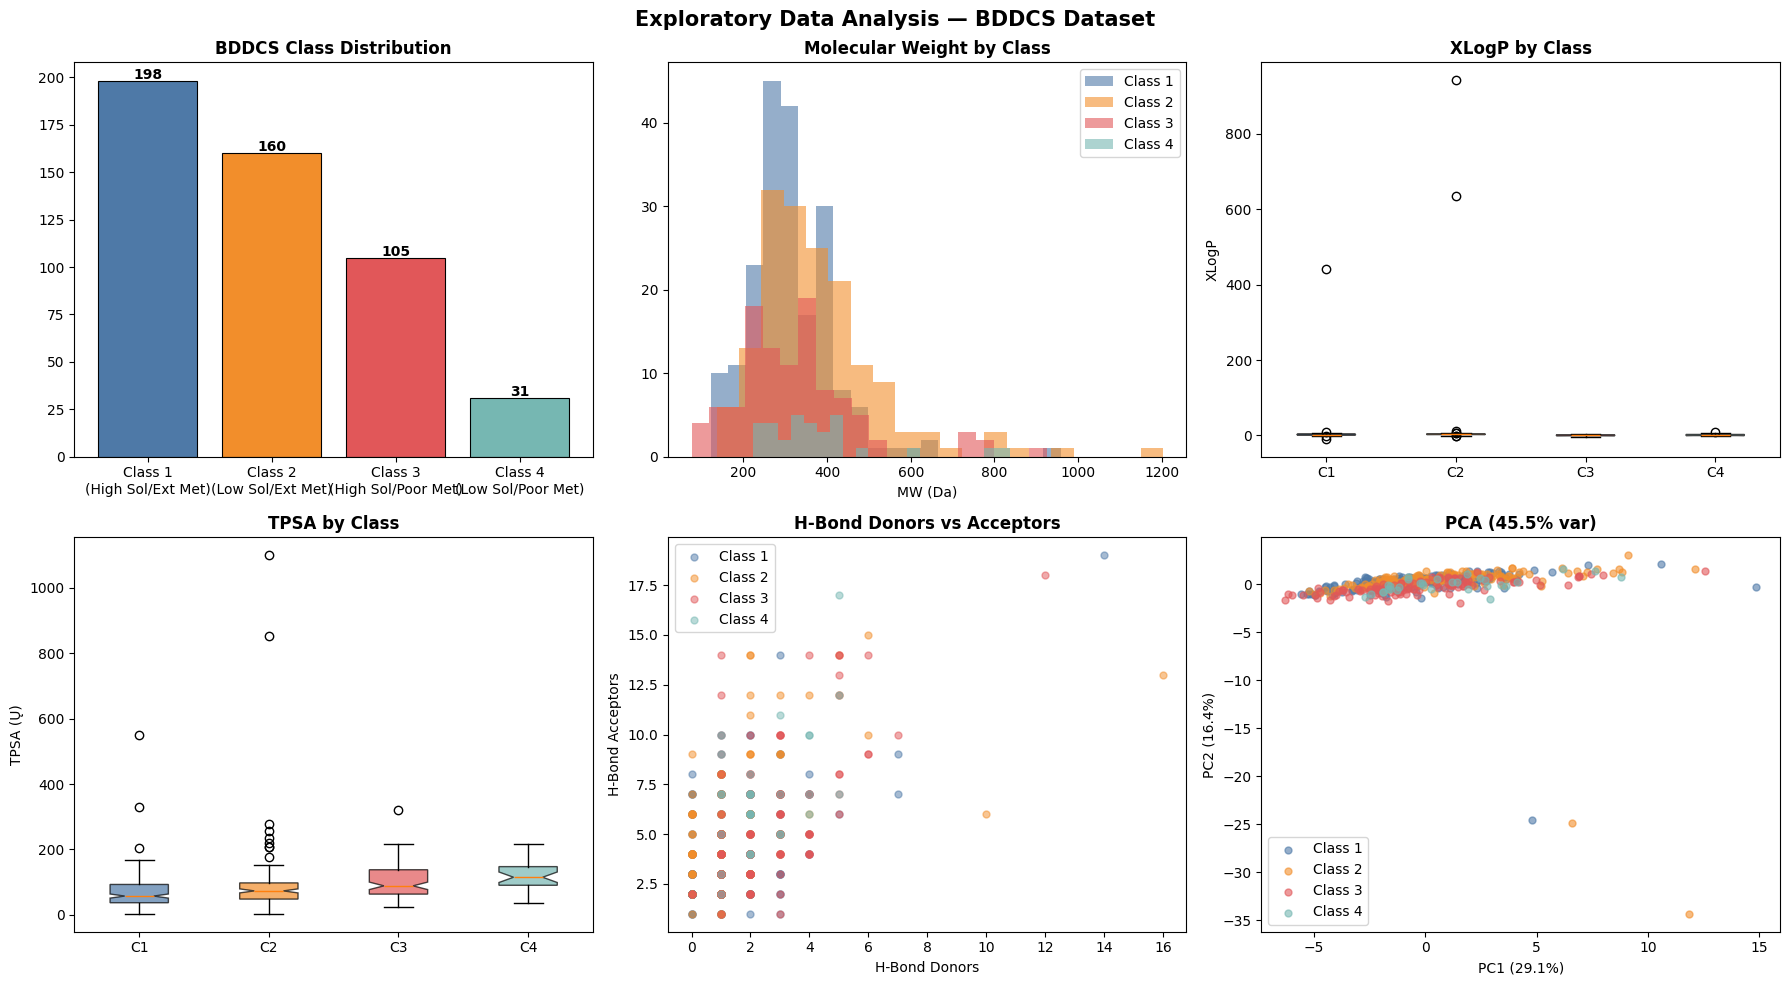

EDA saved as EDA_BDDCS.png


In [9]:
COLORS = ['#4e79a7','#f28e2b','#e15759','#76b7b2']
CLASS_LABELS = ['Class 1\n(High Sol/Ext Met)', 'Class 2\n(Low Sol/Ext Met)',
                'Class 3\n(High Sol/Poor Met)','Class 4\n(Low Sol/Poor Met)']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Exploratory Data Analysis — BDDCS Dataset', fontsize=15, fontweight='bold')

# 1. Class distribution
counts = props_df['BDDCS'].value_counts().sort_index()
bars = axes[0,0].bar(CLASS_LABELS, counts.values, color=COLORS, edgecolor='black', lw=0.8)
axes[0,0].set_title('BDDCS Class Distribution', fontweight='bold')
for bar,v in zip(bars,counts.values):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, v+1, str(v), ha='center', fontweight='bold')

# 2. Molecular Weight distribution
for cls,col in zip([1,2,3,4], COLORS):
    axes[0,1].hist(props_df[props_df['BDDCS']==cls]['MolecularWeight'],
                   bins=20, alpha=0.6, color=col, label=f'Class {cls}')
axes[0,1].set_title('Molecular Weight by Class', fontweight='bold')
axes[0,1].set_xlabel('MW (Da)'); axes[0,1].legend()

# 3. XLogP boxplot
data_logp = [props_df[props_df['BDDCS']==c]['XLogP'].values for c in [1,2,3,4]]
bp = axes[0,2].boxplot(data_logp, patch_artist=True,
                        labels=['C1','C2','C3','C4'], notch=True)
for patch,col in zip(bp['boxes'], COLORS):
    patch.set_facecolor(col); patch.set_alpha(0.7)
axes[0,2].set_title('XLogP by Class', fontweight='bold')
axes[0,2].set_ylabel('XLogP')

# 4. TPSA boxplot
data_tpsa = [props_df[props_df['BDDCS']==c]['TPSA'].values for c in [1,2,3,4]]
bp2 = axes[1,0].boxplot(data_tpsa, patch_artist=True,
                          labels=['C1','C2','C3','C4'], notch=True)
for patch,col in zip(bp2['boxes'], COLORS):
    patch.set_facecolor(col); patch.set_alpha(0.7)
axes[1,0].set_title('TPSA by Class', fontweight='bold')
axes[1,0].set_ylabel('TPSA (Ų)')

# 5. HBD vs HBA scatter
for cls,col in zip([1,2,3,4], COLORS):
    sub = props_df[props_df['BDDCS']==cls]
    axes[1,1].scatter(sub['HBondDonorCount'], sub['HBondAcceptorCount'],
                      alpha=0.5, color=col, label=f'Class {cls}', s=25)
axes[1,1].set_title('H-Bond Donors vs Acceptors', fontweight='bold')
axes[1,1].set_xlabel('H-Bond Donors'); axes[1,1].set_ylabel('H-Bond Acceptors')
axes[1,1].legend()

# 6. PCA 2D
feat_cols = [c for c in props_df.columns if c != 'BDDCS']
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(StandardScaler().fit_transform(props_df[feat_cols].fillna(0)))
for cls,col in zip([1,2,3,4], COLORS):
    mask = props_df['BDDCS'].values == cls
    axes[1,2].scatter(X_pca[mask,0], X_pca[mask,1], alpha=0.6,
                      color=col, label=f'Class {cls}', s=25)
axes[1,2].set_title(f'PCA ({pca.explained_variance_ratio_.sum()*100:.1f}% var)', fontweight='bold')
axes[1,2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1,2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('EDA_BDDCS.png', dpi=300, bbox_inches='tight')
plt.show()
print('EDA saved as EDA_BDDCS.png')

## Section 4 — Feature Preparation & Data Split

In [10]:
import numpy as np
from sklearn.model_selection import train_test_split

FEAT_COLS = [c for c in props_df.columns if c != 'BDDCS']

X_all = props_df[FEAT_COLS].values.astype(np.float64)
y_all = props_df['BDDCS'].values.astype(int)

# Stratified 80/20 split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.20, random_state=42, stratify=y_all)

print(f'Train: {X_train_raw.shape[0]} samples | Test: {X_test_raw.shape[0]} samples')
print(f'Train class dist: {Counter(y_train)}')
print(f'Test  class dist: {Counter(y_test)}')
print(f'Features        : {X_all.shape[1]}')

Train: 395 samples | Test: 99 samples
Train class dist: Counter({np.int64(1): 158, np.int64(2): 128, np.int64(3): 84, np.int64(4): 25})
Test  class dist: Counter({np.int64(1): 40, np.int64(2): 32, np.int64(3): 21, np.int64(4): 6})
Features        : 33


## Section 5 — Preprocessing: Scaling + SMOTETomek

In [11]:
from sklearn.preprocessing import StandardScaler
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from collections import Counter

# Scale — fit only on train to avoid leakage
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_raw)
X_test_sc  = scaler.transform(X_test_raw)

# SMOTETomek: oversample minority then clean borderline majority samples
smt = SMOTETomek(smote=SMOTE(k_neighbors=3, random_state=42), random_state=42)
X_train_sm, y_train_sm = smt.fit_resample(X_train_sc, y_train)

print(f'Before resampling : {Counter(y_train)}')
print(f'After  resampling : {Counter(y_train_sm)}')
print(f'Training set size : {len(X_train_raw)} → {len(X_train_sm)}')

Before resampling : Counter({np.int64(1): 158, np.int64(2): 128, np.int64(3): 84, np.int64(4): 25})
After  resampling : Counter({np.int64(4): 157, np.int64(3): 155, np.int64(2): 145, np.int64(1): 141})
Training set size : 395 → 598


## Section 6 — Advanced ML Models (one cell each)

In [12]:
#Random Forest (tuned, balanced)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, matthews_corrcoef, f1_score

rf = RandomForestClassifier(
    n_estimators=500, max_depth=None, min_samples_leaf=1,
    max_features='sqrt', class_weight='balanced',
    random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)
rf_pred = rf.predict(X_test_sc)

print('Accuracy of Random Forest on training set: {:.2f}'.format(rf.score(X_train_sm, y_train_sm)))
print('Accuracy of Random Forest on test set: {:.2f}'.format(accuracy_score(y_test, rf_pred)))
print('MCC: {:.4f} | F1w: {:.4f}'.format(matthews_corrcoef(y_test, rf_pred),
                                           f1_score(y_test, rf_pred, average='weighted')))

Accuracy of Random Forest on training set: 1.00
Accuracy of Random Forest on test set: 0.55
MCC: 0.3628 | F1w: 0.5647


In [13]:
#Extra Trees Classifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, matthews_corrcoef, f1_score

et = ExtraTreesClassifier(
    n_estimators=500, max_features='sqrt',
    class_weight='balanced', random_state=42, n_jobs=-1)
et.fit(X_train_sm, y_train_sm)
et_pred = et.predict(X_test_sc)

print('Accuracy of Extra Trees on training set: {:.2f}'.format(et.score(X_train_sm, y_train_sm)))
print('Accuracy of Extra Trees on test set: {:.2f}'.format(accuracy_score(y_test, et_pred)))
print('MCC: {:.4f} | F1w: {:.4f}'.format(matthews_corrcoef(y_test, et_pred),
                                           f1_score(y_test, et_pred, average='weighted')))

Accuracy of Extra Trees on training set: 1.00
Accuracy of Extra Trees on test set: 0.59
MCC: 0.4066 | F1w: 0.5982


In [14]:
#XGBoost Classifier (tuned)
import xgboost as xgb
from sklearn.metrics import accuracy_score, matthews_corrcoef, f1_score

xgb_clf = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    reg_alpha=0.1, reg_lambda=1.0,
    eval_metric='mlogloss', use_label_encoder=False,
    random_state=42, verbosity=0, n_jobs=-1)
# XGBoost requires 0-indexed labels
xgb_clf.fit(X_train_sm, y_train_sm - 1,
            eval_set=[(X_test_sc, y_test - 1)], verbose=False)
xgb_pred = xgb_clf.predict(X_test_sc) + 1

print('Accuracy of XGBoost on training set: {:.2f}'.format(
    accuracy_score(y_train_sm, xgb_clf.predict(X_train_sm) + 1)))
print('Accuracy of XGBoost on test set: {:.2f}'.format(accuracy_score(y_test, xgb_pred)))
print('MCC: {:.4f} | F1w: {:.4f}'.format(matthews_corrcoef(y_test, xgb_pred),
                                           f1_score(y_test, xgb_pred, average='weighted')))

Accuracy of XGBoost on training set: 1.00
Accuracy of XGBoost on test set: 0.54
MCC: 0.3297 | F1w: 0.5415


In [15]:
#LightGBM Classifier (tuned)
import lightgbm as lgb
from sklearn.metrics import accuracy_score, matthews_corrcoef, f1_score

lgb_clf = lgb.LGBMClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.03,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    class_weight='balanced', random_state=42, verbose=-1, n_jobs=-1)
lgb_clf.fit(X_train_sm, y_train_sm)
lgb_pred = lgb_clf.predict(X_test_sc)

print('Accuracy of LightGBM on training set: {:.2f}'.format(lgb_clf.score(X_train_sm, y_train_sm)))
print('Accuracy of LightGBM on test set: {:.2f}'.format(accuracy_score(y_test, lgb_pred)))
print('MCC: {:.4f} | F1w: {:.4f}'.format(matthews_corrcoef(y_test, lgb_pred),
                                           f1_score(y_test, lgb_pred, average='weighted')))

Accuracy of LightGBM on training set: 1.00
Accuracy of LightGBM on test set: 0.53
MCC: 0.3131 | F1w: 0.5311


In [16]:
#CatBoost Classifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, matthews_corrcoef, f1_score

cat_clf = CatBoostClassifier(
    iterations=500, depth=6, learning_rate=0.03,
    l2_leaf_reg=3, random_seed=42, verbose=0,
    auto_class_weights='Balanced')
cat_clf.fit(X_train_sm, y_train_sm)
cat_pred = cat_clf.predict(X_test_sc).flatten().astype(int)

print('Accuracy of CatBoost on training set: {:.2f}'.format(
    accuracy_score(y_train_sm, cat_clf.predict(X_train_sm).flatten())))
print('Accuracy of CatBoost on test set: {:.2f}'.format(accuracy_score(y_test, cat_pred)))
print('MCC: {:.4f} | F1w: {:.4f}'.format(matthews_corrcoef(y_test, cat_pred),
                                           f1_score(y_test, cat_pred, average='weighted')))

Accuracy of CatBoost on training set: 0.97
Accuracy of CatBoost on test set: 0.54
MCC: 0.3519 | F1w: 0.5499


In [17]:
#SVM with RBF kernel (tuned)
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, matthews_corrcoef, f1_score

svm_clf = SVC(C=10, gamma='scale', kernel='rbf',
               class_weight='balanced', probability=True, random_state=42)
svm_clf.fit(X_train_sm, y_train_sm)
svm_pred = svm_clf.predict(X_test_sc)

print('Accuracy of SVM on training set: {:.2f}'.format(svm_clf.score(X_train_sm, y_train_sm)))
print('Accuracy of SVM on test set: {:.2f}'.format(accuracy_score(y_test, svm_pred)))
print('MCC: {:.4f} | F1w: {:.4f}'.format(matthews_corrcoef(y_test, svm_pred),
                                           f1_score(y_test, svm_pred, average='weighted')))

Accuracy of SVM on training set: 0.96
Accuracy of SVM on test set: 0.52
MCC: 0.3095 | F1w: 0.5166


In [18]:
#K-Nearest Neighbours (tuned)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, matthews_corrcoef, f1_score

knn_clf = KNeighborsClassifier(n_neighbors=7, weights='distance', metric='euclidean')
knn_clf.fit(X_train_sm, y_train_sm)
knn_pred = knn_clf.predict(X_test_sc)

print('Accuracy of K-NN on training set: {:.2f}'.format(knn_clf.score(X_train_sm, y_train_sm)))
print('Accuracy of K-NN on test set: {:.2f}'.format(accuracy_score(y_test, knn_pred)))
print('MCC: {:.4f} | F1w: {:.4f}'.format(matthews_corrcoef(y_test, knn_pred),
                                           f1_score(y_test, knn_pred, average='weighted')))

Accuracy of K-NN on training set: 1.00
Accuracy of K-NN on test set: 0.42
MCC: 0.2143 | F1w: 0.4460


In [19]:
#Linear Discriminant Analysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, matthews_corrcoef, f1_score

lda_clf = LinearDiscriminantAnalysis(solver='svd')
lda_clf.fit(X_train_sm, y_train_sm)
lda_pred = lda_clf.predict(X_test_sc)

print('Accuracy of LDA on training set: {:.2f}'.format(lda_clf.score(X_train_sm, y_train_sm)))
print('Accuracy of LDA on test set: {:.2f}'.format(accuracy_score(y_test, lda_pred)))
print('MCC: {:.4f} | F1w: {:.4f}'.format(matthews_corrcoef(y_test, lda_pred),
                                           f1_score(y_test, lda_pred, average='weighted')))

Accuracy of LDA on training set: 0.71
Accuracy of LDA on test set: 0.39
MCC: 0.1864 | F1w: 0.4264


In [20]:
#Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, matthews_corrcoef, f1_score

gnb_clf = GaussianNB()
gnb_clf.fit(X_train_sm, y_train_sm)
gnb_pred = gnb_clf.predict(X_test_sc)

print('Accuracy of GNB on training set: {:.2f}'.format(gnb_clf.score(X_train_sm, y_train_sm)))
print('Accuracy of GNB on test set: {:.2f}'.format(accuracy_score(y_test, gnb_pred)))
print('MCC: {:.4f} | F1w: {:.4f}'.format(matthews_corrcoef(y_test, gnb_pred),
                                           f1_score(y_test, gnb_pred, average='weighted')))

Accuracy of GNB on training set: 0.36
Accuracy of GNB on test set: 0.09
MCC: -0.0240 | F1w: 0.0723


In [21]:
#Decision Tree (tuned)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, matthews_corrcoef, f1_score

dt_clf = DecisionTreeClassifier(
    max_depth=10, min_samples_leaf=2,
    class_weight='balanced', random_state=42)
dt_clf.fit(X_train_sm, y_train_sm)
dt_pred = dt_clf.predict(X_test_sc)

print('Accuracy of Decision Tree on training set: {:.2f}'.format(dt_clf.score(X_train_sm, y_train_sm)))
print('Accuracy of Decision Tree on test set: {:.2f}'.format(accuracy_score(y_test, dt_pred)))
print('MCC: {:.4f} | F1w: {:.4f}'.format(matthews_corrcoef(y_test, dt_pred),
                                           f1_score(y_test, dt_pred, average='weighted')))

Accuracy of Decision Tree on training set: 0.95
Accuracy of Decision Tree on test set: 0.45
MCC: 0.2124 | F1w: 0.4618


## Section 7 — Stacking Ensemble (Meta-Learner)

In [22]:
#Stacking Classifier — best base learners + logistic regression meta-learner
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, matthews_corrcoef, f1_score

base_learners = [
    ('rf',  RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                    random_state=42, n_jobs=-1)),
    ('et',  ExtraTreesClassifier(n_estimators=300, class_weight='balanced',
                                  random_state=42, n_jobs=-1)),
    ('xgb', xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                eval_metric='mlogloss', verbosity=0,
                                random_state=42, n_jobs=-1)),
    ('lgb', lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                 class_weight='balanced', verbose=-1,
                                 random_state=42, n_jobs=-1)),
    ('svm', SVC(C=10, kernel='rbf', class_weight='balanced',
                 probability=True, random_state=42)),
]

stack_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(max_iter=1000, C=1.0,
                                        class_weight='balanced', random_state=42),
    cv=5, passthrough=False, n_jobs=-1)

stack_clf.fit(X_train_sm, y_train_sm)
stack_pred = stack_clf.predict(X_test_sc)

print('Accuracy of Stacking Ensemble on training set: {:.2f}'.format(
    accuracy_score(y_train_sm, stack_clf.predict(X_train_sm))))
print('Accuracy of Stacking Ensemble on test set: {:.2f}'.format(
    accuracy_score(y_test, stack_pred)))
print('MCC: {:.4f} | F1w: {:.4f}'.format(matthews_corrcoef(y_test, stack_pred),
                                           f1_score(y_test, stack_pred, average='weighted')))

Accuracy of Stacking Ensemble on training set: 1.00
Accuracy of Stacking Ensemble on test set: 0.56
MCC: 0.3540 | F1w: 0.5597


## Section 8 — 5-Fold Stratified Cross-Validation (All ML Models)

In [23]:
import time
from sklearn.model_selection import StratifiedKFold, cross_validate

ML_MODELS = {
    'Random Forest':     rf,
    'Extra Trees':       et,
    'XGBoost':           xgb_clf,
    'LightGBM':          lgb_clf,
    'CatBoost':          cat_clf,
    'SVM (RBF)':         svm_clf,
    'K-NN':              knn_clf,
    'LDA':               lda_clf,
    'Naive Bayes':       gnb_clf,
    'Decision Tree':     dt_clf,
    'Stacking Ensemble': stack_clf,
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print('5-Fold Stratified Cross-Validation')
print('=' * 72)
for name, model in ML_MODELS.items():
    t0 = time.time()
    # XGBoost expects 0-indexed labels (0, 1, 2, 3) for internal fit
    y_target_cv = y_train_sm - 1 if name == 'XGBoost' else y_train_sm
    cv = cross_validate(model, X_train_sm, y_target_cv, cv=skf,
                        scoring=['accuracy','f1_weighted','f1_macro'], n_jobs=-1)
    cv_results[name] = cv
    print(f'{name:<22}  Acc: {cv["test_accuracy"].mean():.4f}+/-{cv["test_accuracy"].std():.4f}  '
          f'F1w: {cv["test_f1_weighted"].mean():.4f}  '
          f'F1m: {cv["test_f1_macro"].mean():.4f}  [{time.time()-t0:.1f}s]')
print('=' * 72)

5-Fold Stratified Cross-Validation
Random Forest           Acc: 0.7960+/-0.0211  F1w: 0.7922  F1m: 0.7881  [7.0s]
Extra Trees             Acc: 0.8094+/-0.0275  F1w: 0.8073  F1m: 0.8030  [6.7s]
XGBoost                 Acc: 0.7943+/-0.0215  F1w: 0.7923  F1m: 0.7881  [8.4s]
LightGBM                Acc: 0.7993+/-0.0245  F1w: 0.7977  F1m: 0.7937  [16.6s]
CatBoost                Acc: 0.7910+/-0.0104  F1w: 0.7875  F1m: 0.7837  [50.4s]
SVM (RBF)               Acc: 0.8044+/-0.0124  F1w: 0.8016  F1m: 0.7975  [0.5s]
K-NN                    Acc: 0.7526+/-0.0311  F1w: 0.7419  F1m: 0.7383  [0.1s]
LDA                     Acc: 0.6488+/-0.0440  F1w: 0.6469  F1m: 0.6443  [0.1s]
Naive Bayes             Acc: 0.3663+/-0.0453  F1w: 0.2709  F1m: 0.2637  [0.1s]
Decision Tree           Acc: 0.6654+/-0.0683  F1w: 0.6667  F1m: 0.6631  [0.1s]
Stacking Ensemble       Acc: 0.8311+/-0.0200  F1w: 0.8312  F1m: 0.8272  [180.5s]


## Section 9 — ML Results Summary Table

In [24]:
import pandas as pd
from sklearn.metrics import (accuracy_score, f1_score, matthews_corrcoef,
                              roc_auc_score, cohen_kappa_score)
from sklearn.preprocessing import label_binarize

y_bin = label_binarize(y_test, classes=[1,2,3,4])

ml_preds = {
    'Random Forest':     rf_pred,
    'Extra Trees':       et_pred,
    'XGBoost':           xgb_pred,
    'LightGBM':          lgb_pred,
    'CatBoost':          cat_pred,
    'SVM (RBF)':         svm_pred,
    'K-NN':              knn_pred,
    'LDA':               lda_pred,
    'Naive Bayes':       gnb_pred,
    'Decision Tree':     dt_pred,
    'Stacking Ensemble': stack_pred,
}
ml_models_ref = {
    'Random Forest': rf, 'Extra Trees': et, 'XGBoost': xgb_clf,
    'LightGBM': lgb_clf, 'CatBoost': cat_clf, 'SVM (RBF)': svm_clf,
    'K-NN': knn_clf, 'LDA': lda_clf, 'Naive Bayes': gnb_clf,
    'Decision Tree': dt_clf, 'Stacking Ensemble': stack_clf,
}

records = []
for name, y_pred in ml_preds.items():
    model = ml_models_ref[name]
    try:
        prob = model.predict_proba(X_test_sc)
        if name == 'XGBoost':
            # proba is already in 0-3 class order
            pass
        auc = roc_auc_score(y_bin, prob, multi_class='ovr', average='weighted')
    except Exception:
        auc = float('nan')
    records.append({
        'Model':         name,
        'Test Acc':      round(accuracy_score(y_test, y_pred), 4),
        'MCC':           round(matthews_corrcoef(y_test, y_pred), 4),
        'F1 Weighted':   round(f1_score(y_test, y_pred, average='weighted'), 4),
        'F1 Macro':      round(f1_score(y_test, y_pred, average='macro'), 4),
        'Kappa':         round(cohen_kappa_score(y_test, y_pred), 4),
        'ROC-AUC':       round(auc, 4) if auc == auc else 'N/A',
        'CV Acc':        round(cv_results[name]['test_accuracy'].mean(), 4),
        'CV Acc Std':    round(cv_results[name]['test_accuracy'].std(), 4),
    })

ml_results_df = pd.DataFrame(records).sort_values('Test Acc', ascending=False).reset_index(drop=True)
print('ML Model Results (sorted by Test Accuracy):')
display(ml_results_df)

ML Model Results (sorted by Test Accuracy):


,Model,Test Acc,MCC,F1 Weighted,F1 Macro,Kappa,ROC-AUC,CV Acc,CV Acc Std
0,Extra Trees,0.5859,0.4066,0.5982,0.4942,0.4054,0.7627,0.8094,0.0275
1,Stacking Ensemble,0.5556,0.3540,0.5597,0.4408,0.3533,0.7326,0.8311,0.0200
2,Random Forest,0.5455,0.3628,0.5647,0.4662,0.3596,0.7598,0.7960,0.0211
3,XGBoost,0.5354,0.3297,0.5415,0.4257,0.3293,0.7329,0.7943,0.0215
4,CatBoost,0.5354,0.3519,0.5499,0.4790,0.3482,0.7467,0.7910,0.0104
5,LightGBM,0.5253,0.3131,0.5311,0.4152,0.3128,0.7307,0.7993,0.0245
6,SVM (RBF),0.5152,0.3095,0.5166,0.4383,0.3073,0.6981,0.8044,0.0124
7,Decision Tree,0.4545,0.2124,0.4618,0.3649,0.2122,0.6448,0.6654,0.0683
8,K-NN,0.4242,0.2143,0.4460,0.3826,0.2097,0.6951,0.7526,0.0311
9,LDA,0.3939,0.1864,0.4264,0.3505,0.1794,0.6839,0.6488,0.0440


## Section 10 — ML Confusion Matrices

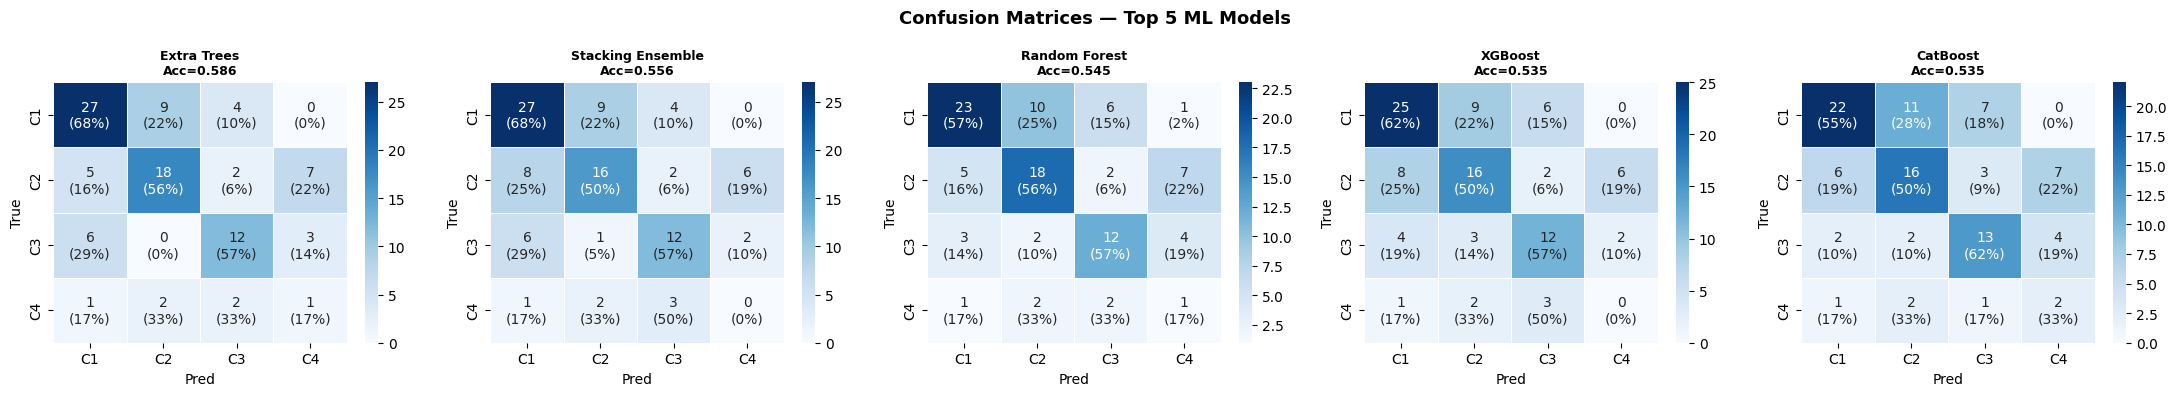

Saved as BDDCS_ML_confusion.png


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

top5 = ml_results_df['Model'].head(5).tolist()

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('Confusion Matrices — Top 5 ML Models', fontsize=13, fontweight='bold')

for ax, name in zip(axes, top5):
    cm = confusion_matrix(y_test, ml_preds[name], labels=[1,2,3,4])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot = np.array([[f'{v}\n({p:.0f}%)' for v,p in zip(row_v, row_p)]
                       for row_v, row_p in zip(cm, cm_pct)])
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=ax,
                xticklabels=['C1','C2','C3','C4'],
                yticklabels=['C1','C2','C3','C4'], linewidths=0.5)
    acc = accuracy_score(y_test, ml_preds[name])
    ax.set_title(f'{name}\nAcc={acc:.3f}', fontweight='bold', fontsize=9)
    ax.set_ylabel('True'); ax.set_xlabel('Pred')

plt.tight_layout()
plt.savefig('BDDCS_ML_confusion.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved as BDDCS_ML_confusion.png')

## Section 11 — SHAP Feature Importance

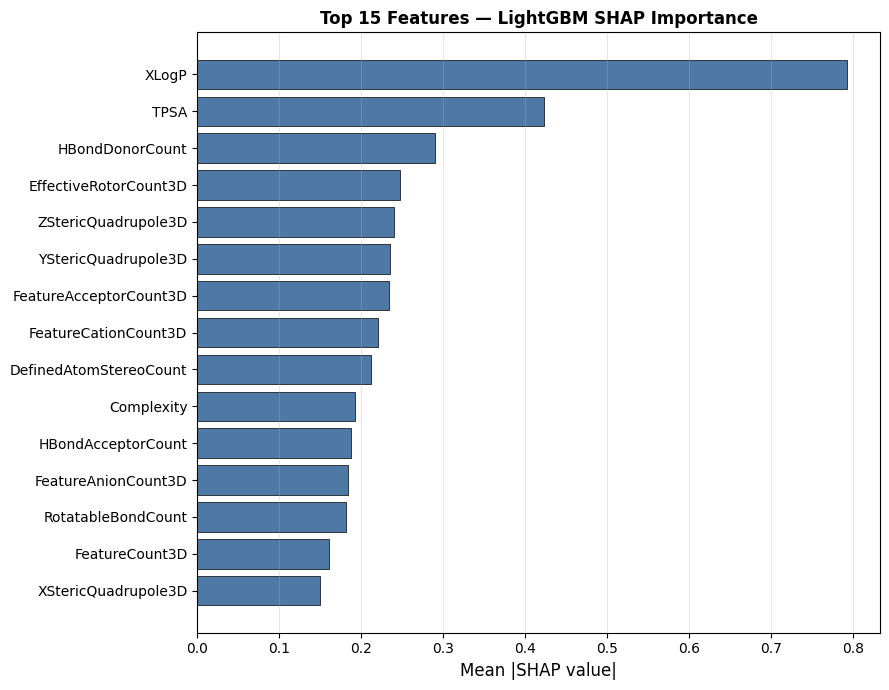

Saved as BDDCS_SHAP.png


In [26]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# Use LightGBM (fast TreeExplainer)
explainer = shap.TreeExplainer(lgb_clf)
shap_vals  = explainer.shap_values(X_test_sc)

# Mean |SHAP| across all classes and samples
if isinstance(shap_vals, list):
    # For multi-output, shap_values might return a list of arrays (n_samples, n_features)
    # each corresponding to a class. Average across classes, then across samples.
    mean_abs = np.mean([np.abs(sv) for sv in shap_vals], axis=0).mean(0)
else:
    # For multi-class, shap_values typically returns (n_samples, n_features, n_classes)
    # First, average absolute SHAP values across samples to get (n_features, n_classes)
    # Then, average this across classes to get (n_features,) overall importance per feature
    mean_abs = np.abs(shap_vals).mean(0).mean(1)

top_idx   = np.argsort(mean_abs)[::-1][:15]
top_names = [FEAT_COLS[i] for i in top_idx]
top_vals  = mean_abs[top_idx]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(range(15), top_vals[::-1], color='#4e79a7', edgecolor='black', lw=0.5)
ax.set_yticks(range(15))
ax.set_yticklabels(top_names[::-1], fontsize=10)
ax.set_xlabel('Mean |SHAP value|', fontsize=12)
ax.set_title('Top 15 Features — LightGBM SHAP Importance', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('BDDCS_SHAP.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved as BDDCS_SHAP.png')

---
## Section 12 — Deep Learning: Architecture Definitions

Four architectures:
- **Residual MLP** — skip connections prevent gradient vanishing
- **1D-CNN** — learns local feature interactions via convolution
- **Attention-MLP** — self-attention gate learns which features to focus on
- **Transformer** — multi-head self-attention over feature tokens

In [27]:
import torch
import torch.nn as nn

N_FEATURES = X_train_sm.shape[1]
N_CLASSES  = 4

# ── Residual block used in Residual-MLP ───────────────────────────────────────
class ResBlock(nn.Module):
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim), nn.BatchNorm1d(dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(dim, dim), nn.BatchNorm1d(dim))
        self.act = nn.GELU()
    def forward(self, x):
        return self.act(x + self.block(x))

# ── Architecture 1: Residual MLP ─────────────────────────────────────────────
class ResidualMLP(nn.Module):
    def __init__(self, in_dim, hidden=256, n_blocks=4, n_classes=4, dropout=0.3):
        super().__init__()
        self.embed = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.BatchNorm1d(hidden), nn.GELU())
        self.blocks = nn.Sequential(*[ResBlock(hidden, dropout) for _ in range(n_blocks)])
        self.head   = nn.Linear(hidden, n_classes)
    def forward(self, x):
        return self.head(self.blocks(self.embed(x)))

# ── Architecture 2: 1D-CNN ────────────────────────────────────────────────────
class CNN1D(nn.Module):
    def __init__(self, in_dim, n_classes=4, dropout=0.3):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 64,  7, padding=3), nn.BatchNorm1d(64),  nn.GELU(), nn.MaxPool1d(2),
            nn.Conv1d(64,128, 5, padding=2), nn.BatchNorm1d(128), nn.GELU(), nn.MaxPool1d(2),
            nn.Conv1d(128,256,3, padding=1), nn.BatchNorm1d(256), nn.GELU(),
            nn.AdaptiveAvgPool1d(8))
        self.fc = nn.Sequential(
            nn.Linear(256*8, 512), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(512, 256),   nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, n_classes))
    def forward(self, x):
        return self.fc(self.conv(x.unsqueeze(1)).view(x.size(0),-1))

# ── Architecture 3: Attention-MLP ────────────────────────────────────────────
class AttentionMLP(nn.Module):
    def __init__(self, in_dim, n_classes=4, dropout=0.3):
        super().__init__()
        # Feature-wise attention gate
        self.gate = nn.Sequential(
            nn.Linear(in_dim, in_dim), nn.LayerNorm(in_dim),
            nn.Tanh(),
            nn.Linear(in_dim, in_dim), nn.Sigmoid())
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, 512), nn.BatchNorm1d(512), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(512, 256),    nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, 128),    nn.GELU(),
            nn.Linear(128, n_classes))
    def forward(self, x):
        return self.mlp(self.gate(x) * x)

# ── Architecture 4: Feature-Tokenizer Transformer ────────────────────────────
class FeatureTransformer(nn.Module):
    """Treats each scalar feature as a 1D token (d_token-dim embedding),
    applies multi-head self-attention, then classifies via CLS token."""
    def __init__(self, in_dim, d_token=32, n_heads=4, n_layers=2,
                 n_classes=4, dropout=0.1):
        super().__init__()
        # Project each of the in_dim scalar features → d_token embedding
        self.token_proj = nn.Linear(1, d_token)
        self.cls_token  = nn.Parameter(torch.zeros(1, 1, d_token))
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_token, nhead=n_heads, dim_feedforward=d_token*4,
            dropout=dropout, batch_first=True, norm_first=True,
            activation='gelu')
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers,
                                              enable_nested_tensor=False)
        self.head = nn.Sequential(
            nn.LayerNorm(d_token),
            nn.Linear(d_token, n_classes))
    def forward(self, x):                    # x: (B, in_dim)
        B = x.size(0)
        tokens = self.token_proj(x.unsqueeze(-1))          # (B, in_dim, d_token)
        cls    = self.cls_token.expand(B, -1, -1)          # (B, 1, d_token)
        tokens = torch.cat([cls, tokens], dim=1)           # (B, in_dim+1, d_token)
        out    = self.encoder(tokens)                      # (B, in_dim+1, d_token)
        return self.head(out[:, 0])                        # CLS token → logits

print(f'Input features : {N_FEATURES} | Classes : {N_CLASSES}')
print('DL architectures defined: ResidualMLP, 1D-CNN, AttentionMLP, FeatureTransformer')

Input features : 33 | Classes : 4
DL architectures defined: ResidualMLP, 1D-CNN, AttentionMLP, FeatureTransformer


## Section 13 — DataLoaders

In [28]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

# Carve 10% validation from training set
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_sm, y_train_sm, test_size=0.10, random_state=42, stratify=y_train_sm)

def make_loader(X, y, batch=64, shuffle=False):
    Xt = torch.FloatTensor(X).to(DEVICE)
    yt = torch.LongTensor(y.astype(int) - 1).to(DEVICE)  # 0-indexed
    return DataLoader(TensorDataset(Xt, yt), batch_size=batch, shuffle=shuffle)

train_loader = make_loader(X_tr,      y_tr,    shuffle=True)
val_loader   = make_loader(X_val,     y_val)
test_loader  = make_loader(X_test_sc, y_test)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')

Train batches: 9 | Val batches: 1 | Test batches: 2


## Section 14 — DL Training Loop (Label Smoothing + Cosine LR + Early Stopping)

In [29]:
import torch, torch.nn as nn, torch.optim as optim

def train_dl_model(model, train_loader, val_loader,
                   epochs=200, lr=3e-4, patience=25,
                   label_smoothing=0.1, weight_decay=1e-3):
    """
    AdamW + CosineAnnealingWarmRestarts + LabelSmoothing + EarlyStopping
    """
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=50, T_mult=2, eta_min=1e-6)

    best_val_acc, best_state, no_improve = 0.0, None, 0
    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

    for epoch in range(epochs):
        # ── Train ─────────────────────────────────────────────────────────────
        model.train()
        t_loss, t_cor, t_tot = 0., 0, 0
        for Xb, yb in train_loader:
            optimizer.zero_grad()
            out  = model(Xb)
            loss = criterion(out, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            t_loss += loss.item() * Xb.size(0)
            t_cor  += (out.argmax(1) == yb).sum().item()
            t_tot  += Xb.size(0)
        scheduler.step(epoch)

        # ── Validate ──────────────────────────────────────────────────────────
        model.eval()
        v_loss, v_cor, v_tot = 0., 0, 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                out    = model(Xb)
                v_loss += criterion(out, yb).item() * Xb.size(0)
                v_cor  += (out.argmax(1) == yb).sum().item()
                v_tot  += Xb.size(0)

        t_acc = t_cor / t_tot;  v_acc = v_cor / v_tot
        history['train_loss'].append(t_loss / t_tot)
        history['val_loss'].append(v_loss / v_tot)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        # ── Early stopping ────────────────────────────────────────────────────
        if v_acc > best_val_acc:
            best_val_acc = v_acc
            best_state   = {k: v.cpu().clone() for k,v in model.state_dict().items()}
            no_improve   = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  Early stop @ epoch {epoch+1} | best val acc: {best_val_acc:.4f}')
                break

    model.load_state_dict(best_state)
    return model, history


def evaluate_dl(model, loader):
    """Returns (predictions 1-indexed, probabilities)"""
    model.eval()
    preds, probs = [], []
    with torch.no_grad():
        for Xb, _ in loader:
            out = model(Xb)
            preds.append(out.argmax(1).cpu().numpy() + 1)
            probs.append(torch.softmax(out, 1).cpu().numpy())
    return np.concatenate(preds), np.concatenate(probs)


print('Training utilities defined.')

Training utilities defined.


## Section 15 — Train Residual-MLP

In [30]:
#Train Residual MLP
import torch
from sklearn.metrics import accuracy_score, matthews_corrcoef, f1_score

res_mlp = ResidualMLP(N_FEATURES, hidden=256, n_blocks=4, n_classes=N_CLASSES, dropout=0.3).to(DEVICE)
n_params = sum(p.numel() for p in res_mlp.parameters() if p.requires_grad)
print(f'Residual-MLP | Parameters: {n_params:,}')

res_mlp, res_mlp_hist = train_dl_model(res_mlp, train_loader, val_loader)

res_mlp_pred, res_mlp_prob = evaluate_dl(res_mlp, test_loader)

print('Accuracy of Residual-MLP on training set: {:.2f}'.format(res_mlp_hist['train_acc'][-1]))
print('Accuracy of Residual-MLP on test set: {:.2f}'.format(accuracy_score(y_test, res_mlp_pred)))
print('MCC: {:.4f} | F1w: {:.4f}'.format(matthews_corrcoef(y_test, res_mlp_pred),
                                           f1_score(y_test, res_mlp_pred, average='weighted')))

Residual-MLP | Parameters: 540,676
  Early stop @ epoch 36 | best val acc: 0.8667
Accuracy of Residual-MLP on training set: 0.96
Accuracy of Residual-MLP on test set: 0.47
MCC: 0.2822 | F1w: 0.4992


## Section 16 — Train 1D-CNN

In [31]:
#Train 1D-CNN
import torch
from sklearn.metrics import accuracy_score, matthews_corrcoef, f1_score

cnn1d = CNN1D(N_FEATURES, n_classes=N_CLASSES, dropout=0.3).to(DEVICE)
n_params = sum(p.numel() for p in cnn1d.parameters() if p.requires_grad)
print(f'1D-CNN | Parameters: {n_params:,}')

cnn1d, cnn1d_hist = train_dl_model(cnn1d, train_loader, val_loader)

cnn1d_pred, cnn1d_prob = evaluate_dl(cnn1d, test_loader)

print('Accuracy of 1D-CNN on training set: {:.2f}'.format(cnn1d_hist['train_acc'][-1]))
print('Accuracy of 1D-CNN on test set: {:.2f}'.format(accuracy_score(y_test, cnn1d_pred)))
print('MCC: {:.4f} | F1w: {:.4f}'.format(matthews_corrcoef(y_test, cnn1d_pred),
                                           f1_score(y_test, cnn1d_pred, average='weighted')))

1D-CNN | Parameters: 1,322,500
  Early stop @ epoch 46 | best val acc: 0.8833
Accuracy of 1D-CNN on training set: 1.00
Accuracy of 1D-CNN on test set: 0.52
MCC: 0.3225 | F1w: 0.5261


## Section 17 — Train Attention-MLP

In [32]:
#Train Attention-MLP
import torch
from sklearn.metrics import accuracy_score, matthews_corrcoef, f1_score

attn_mlp = AttentionMLP(N_FEATURES, n_classes=N_CLASSES, dropout=0.3).to(DEVICE)
n_params = sum(p.numel() for p in attn_mlp.parameters() if p.requires_grad)
print(f'Attention-MLP | Parameters: {n_params:,}')

attn_mlp, attn_mlp_hist = train_dl_model(attn_mlp, train_loader, val_loader)

attn_mlp_pred, attn_mlp_prob = evaluate_dl(attn_mlp, test_loader)

print('Accuracy of Attention-MLP on training set: {:.2f}'.format(attn_mlp_hist['train_acc'][-1]))
print('Accuracy of Attention-MLP on test set: {:.2f}'.format(accuracy_score(y_test, attn_mlp_pred)))
print('MCC: {:.4f} | F1w: {:.4f}'.format(matthews_corrcoef(y_test, attn_mlp_pred),
                                           f1_score(y_test, attn_mlp_pred, average='weighted')))

Attention-MLP | Parameters: 185,994
  Early stop @ epoch 48 | best val acc: 0.8833
Accuracy of Attention-MLP on training set: 0.92
Accuracy of Attention-MLP on test set: 0.49
MCC: 0.3101 | F1w: 0.5158


## Section 18 — Train Feature Transformer

In [33]:
#Train Feature-Tokenizer Transformer
import torch
from sklearn.metrics import accuracy_score, matthews_corrcoef, f1_score

feat_trans = FeatureTransformer(
    in_dim=N_FEATURES, d_token=32, n_heads=4,
    n_layers=3, n_classes=N_CLASSES, dropout=0.1).to(DEVICE)
n_params = sum(p.numel() for p in feat_trans.parameters() if p.requires_grad)
print(f'FeatureTransformer | Parameters: {n_params:,}')

feat_trans, feat_trans_hist = train_dl_model(
    feat_trans, train_loader, val_loader,
    epochs=200, lr=1e-3, patience=30, label_smoothing=0.1)

feat_trans_pred, feat_trans_prob = evaluate_dl(feat_trans, test_loader)

print('Accuracy of FeatureTransformer on training set: {:.2f}'.format(feat_trans_hist['train_acc'][-1]))
print('Accuracy of FeatureTransformer on test set: {:.2f}'.format(accuracy_score(y_test, feat_trans_pred)))
print('MCC: {:.4f} | F1w: {:.4f}'.format(matthews_corrcoef(y_test, feat_trans_pred),
                                           f1_score(y_test, feat_trans_pred, average='weighted')))

FeatureTransformer | Parameters: 38,404
  Early stop @ epoch 67 | best val acc: 0.5667
Accuracy of FeatureTransformer on training set: 0.45
Accuracy of FeatureTransformer on test set: 0.27
MCC: 0.0086 | F1w: 0.2886


## Section 19 — DL Training Curves

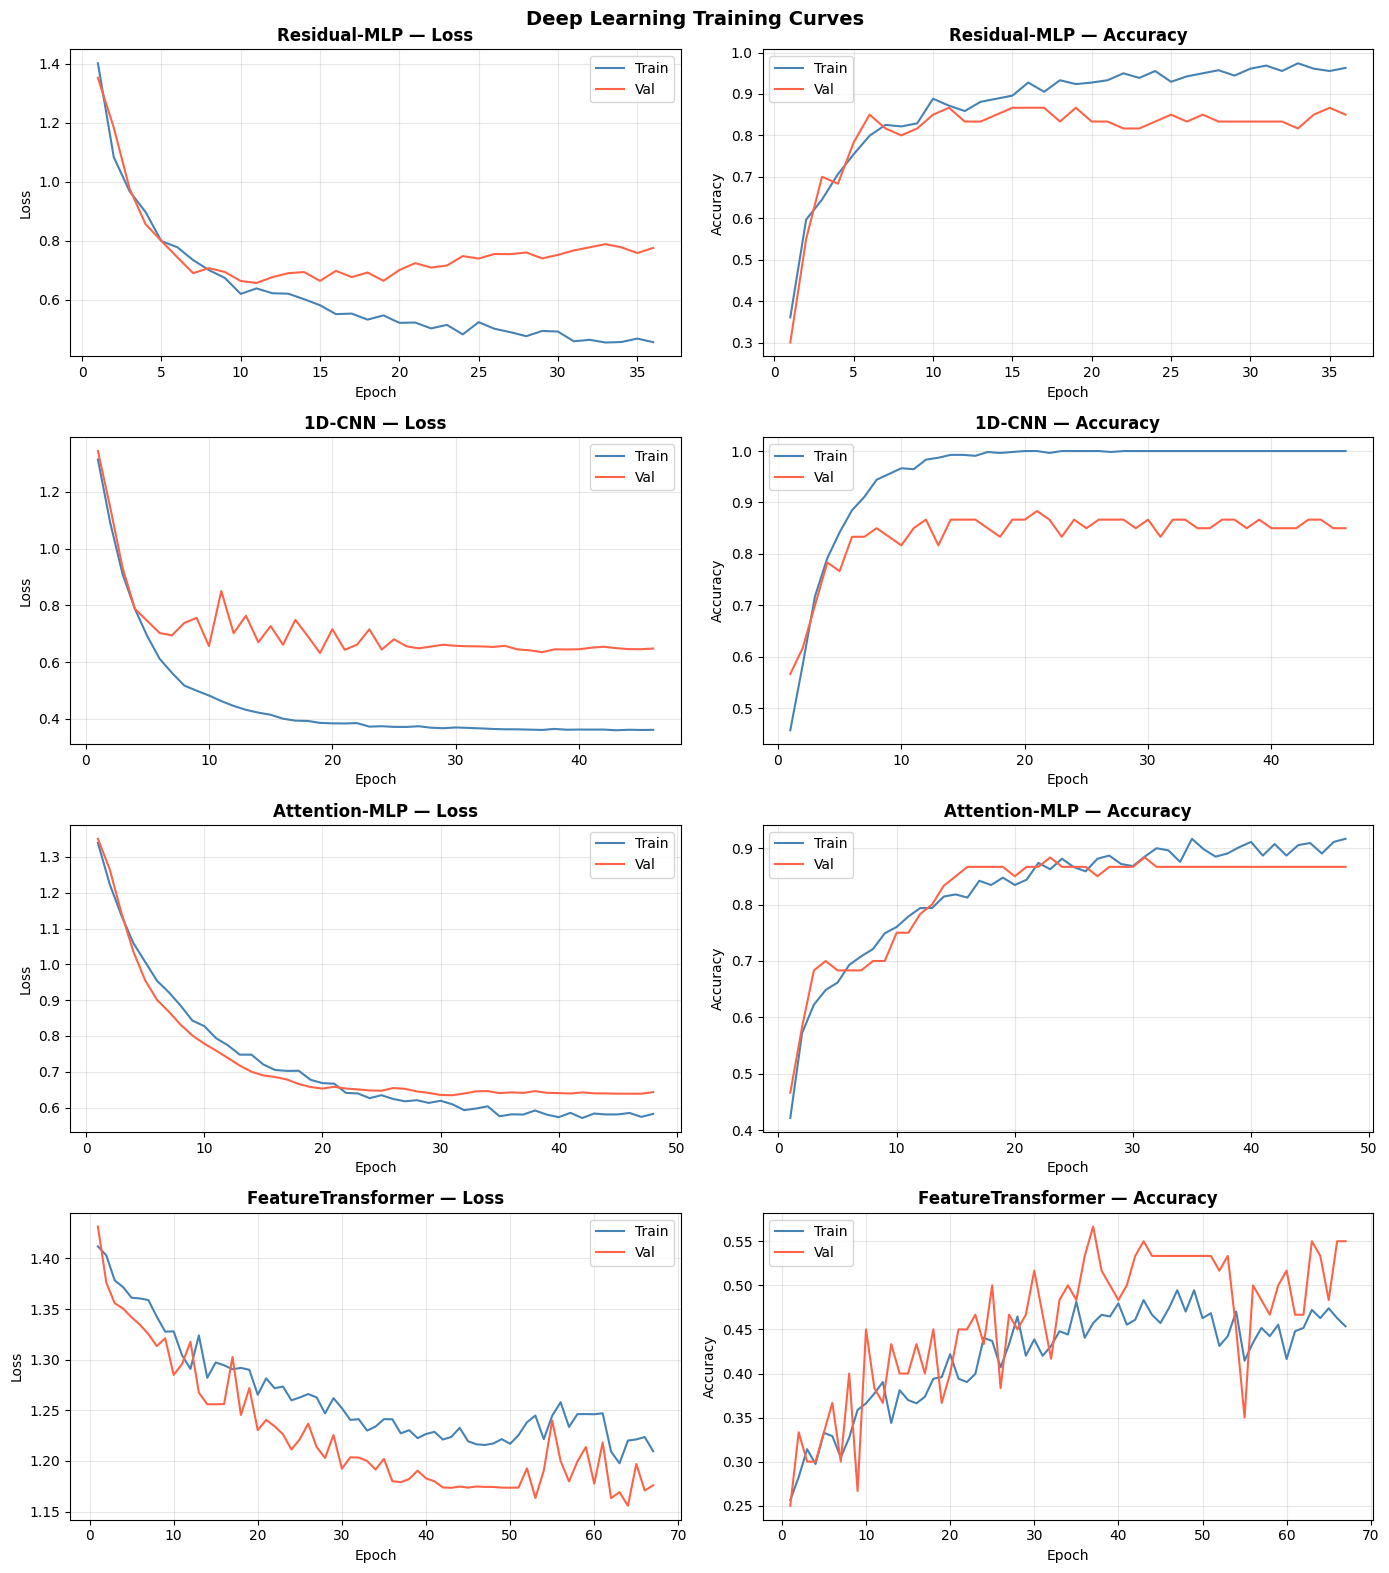

Saved as BDDCS_DL_curves.png


In [34]:
import matplotlib.pyplot as plt

dl_histories = {
    'Residual-MLP':        res_mlp_hist,
    '1D-CNN':              cnn1d_hist,
    'Attention-MLP':       attn_mlp_hist,
    'FeatureTransformer':  feat_trans_hist,
}

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
fig.suptitle('Deep Learning Training Curves', fontsize=14, fontweight='bold')

for i, (name, hist) in enumerate(dl_histories.items()):
    ep = range(1, len(hist['train_loss'])+1)
    axes[i,0].plot(ep, hist['train_loss'], label='Train', color='steelblue', lw=1.5)
    axes[i,0].plot(ep, hist['val_loss'],   label='Val',   color='tomato',    lw=1.5)
    axes[i,0].set_title(f'{name} — Loss', fontweight='bold')
    axes[i,0].set_xlabel('Epoch'); axes[i,0].set_ylabel('Loss')
    axes[i,0].legend(); axes[i,0].grid(alpha=0.3)

    axes[i,1].plot(ep, hist['train_acc'], label='Train', color='steelblue', lw=1.5)
    axes[i,1].plot(ep, hist['val_acc'],   label='Val',   color='tomato',    lw=1.5)
    axes[i,1].set_title(f'{name} — Accuracy', fontweight='bold')
    axes[i,1].set_xlabel('Epoch'); axes[i,1].set_ylabel('Accuracy')
    axes[i,1].legend(); axes[i,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('BDDCS_DL_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved as BDDCS_DL_curves.png')

## Section 20 — Combined Results Table (ML + DL)

In [35]:
import pandas as pd
from sklearn.metrics import (accuracy_score, f1_score, matthews_corrcoef,
                              roc_auc_score, cohen_kappa_score)
from sklearn.preprocessing import label_binarize

y_bin = label_binarize(y_test, classes=[1,2,3,4])

dl_entries = [
    ('Residual-MLP',       res_mlp_pred,       res_mlp_prob),
    ('1D-CNN',             cnn1d_pred,          cnn1d_prob),
    ('Attention-MLP',      attn_mlp_pred,       attn_mlp_prob),
    ('FeatureTransformer', feat_trans_pred,      feat_trans_prob),
]

dl_records = []
for name, y_pred, y_prob in dl_entries:
    auc = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='weighted')
    dl_records.append({
        'Model':       name,
        'Type':        'DL',
        'Test Acc':    round(accuracy_score(y_test, y_pred), 4),
        'MCC':         round(matthews_corrcoef(y_test, y_pred), 4),
        'F1 Weighted': round(f1_score(y_test, y_pred, average='weighted'), 4),
        'F1 Macro':    round(f1_score(y_test, y_pred, average='macro'), 4),
        'Kappa':       round(cohen_kappa_score(y_test, y_pred), 4),
        'ROC-AUC':     round(auc, 4),
        'CV Acc':      'N/A',
        'CV Acc Std':  'N/A',
    })

ml_records = ml_results_df.copy()
ml_records['Type'] = 'ML'
dl_df = pd.DataFrame(dl_records)

all_results_df = pd.concat([ml_records, dl_df], ignore_index=True)\
                   .sort_values('Test Acc', ascending=False).reset_index(drop=True)

print('All Models — Final Results (sorted by Test Accuracy):')
display(all_results_df)

all_results_df.to_csv('BDDCS_all_results.csv', index=False)
print('Saved as BDDCS_all_results.csv')

All Models — Final Results (sorted by Test Accuracy):


,Model,Test Acc,MCC,F1 Weighted,F1 Macro,Kappa,ROC-AUC,CV Acc,CV Acc Std,Type
0,Extra Trees,0.5859,0.4066,0.5982,0.4942,0.4054,0.7627,0.8094,0.0275,ML
1,Stacking Ensemble,0.5556,0.3540,0.5597,0.4408,0.3533,0.7326,0.8311,0.02,ML
2,Random Forest,0.5455,0.3628,0.5647,0.4662,0.3596,0.7598,0.796,0.0211,ML
3,XGBoost,0.5354,0.3297,0.5415,0.4257,0.3293,0.7329,0.7943,0.0215,ML
4,CatBoost,0.5354,0.3519,0.5499,0.4790,0.3482,0.7467,0.791,0.0104,ML
5,LightGBM,0.5253,0.3131,0.5311,0.4152,0.3128,0.7307,0.7993,0.0245,ML
6,SVM (RBF),0.5152,0.3095,0.5166,0.4383,0.3073,0.6981,0.8044,0.0124,ML
7,1D-CNN,0.5152,0.3225,0.5261,0.4416,0.3181,0.7184,N/A,N/A,DL
8,Attention-MLP,0.4949,0.3101,0.5158,0.4471,0.3036,0.7043,N/A,N/A,DL
9,Residual-MLP,0.4747,0.2822,0.4992,0.4113,0.2764,0.7149,N/A,N/A,DL


Saved as BDDCS_all_results.csv


## Section 21 — Deep Ensemble (Soft-Vote Across All DL Models)

In [36]:
import numpy as np
from sklearn.metrics import accuracy_score, matthews_corrcoef, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

# Average predicted probabilities from all 4 DL models
avg_prob    = np.mean([res_mlp_prob, cnn1d_prob, attn_mlp_prob, feat_trans_prob], axis=0)
dl_ens_pred = avg_prob.argmax(axis=1) + 1   # back to 1-indexed

y_bin = label_binarize(y_test, classes=[1,2,3,4])
auc   = roc_auc_score(y_bin, avg_prob, multi_class='ovr', average='weighted')

print('DL Soft-Vote Ensemble Performance:')
print('  Accuracy  : {:.4f}'.format(accuracy_score(y_test, dl_ens_pred)))
print('  MCC       : {:.4f}'.format(matthews_corrcoef(y_test, dl_ens_pred)))
print('  F1 Weighted: {:.4f}'.format(f1_score(y_test, dl_ens_pred, average='weighted')))
print('  ROC-AUC   : {:.4f}'.format(auc))

DL Soft-Vote Ensemble Performance:
  Accuracy  : 0.4848
  MCC       : 0.2889
  F1 Weighted: 0.5010
  ROC-AUC   : 0.7118


## Section 22 — Performance Comparison Figure

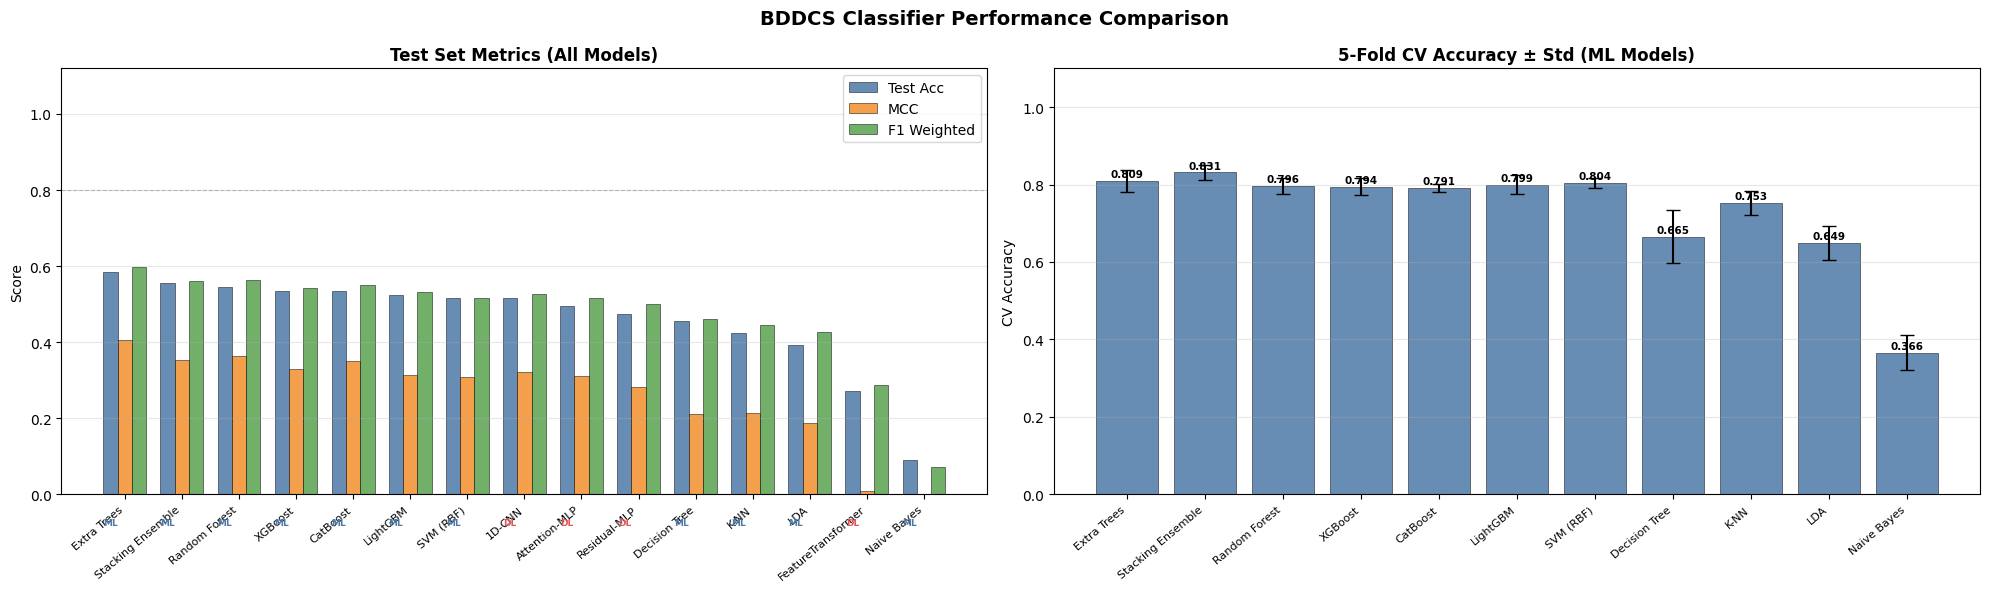

Saved as BDDCS_performance_comparison.png


In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle('BDDCS Classifier Performance Comparison', fontsize=14, fontweight='bold')

models  = all_results_df['Model'].tolist()
types   = all_results_df['Type'].tolist()
acc_v   = pd.to_numeric(all_results_df['Test Acc'], errors='coerce').fillna(0).tolist()
mcc_v   = pd.to_numeric(all_results_df['MCC'],      errors='coerce').fillna(0).tolist()
f1w_v   = pd.to_numeric(all_results_df['F1 Weighted'], errors='coerce').fillna(0).tolist()

x, w = np.arange(len(models)), 0.25
pal  = {'ML': '#4e79a7', 'DL': '#e15759'}
bar_colors = [pal[t] for t in types]

# Left panel — grouped bar (Acc / MCC / F1w)
axes[0].bar(x-w, acc_v, w, label='Test Acc',    color='#4e79a7', alpha=0.85, edgecolor='k', lw=0.4)
axes[0].bar(x,   mcc_v, w, label='MCC',         color='#f28e2b', alpha=0.85, edgecolor='k', lw=0.4)
axes[0].bar(x+w, f1w_v, w, label='F1 Weighted', color='#59a14f', alpha=0.85, edgecolor='k', lw=0.4)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=40, ha='right', fontsize=8)
axes[0].set_ylim(0, 1.12)
axes[0].set_ylabel('Score')
axes[0].set_title('Test Set Metrics (All Models)', fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].axhline(0.8, color='gray', ls='--', lw=0.8, alpha=0.5)
axes[0].grid(axis='y', alpha=0.3)
# ML vs DL tag
for xi, t in zip(x, types):
    axes[0].text(xi-w, -0.08, t, ha='center', fontsize=6.5,
                  color=pal[t], fontweight='bold')

# Right panel — CV accuracy with error bars (ML only)
ml_sub = all_results_df[all_results_df['Type']=='ML'].reset_index(drop=True)
ml_names = ml_sub['Model'].tolist()
cv_means = [cv_results[m]['test_accuracy'].mean() for m in ml_names]
cv_stds  = [cv_results[m]['test_accuracy'].std()  for m in ml_names]
x2 = np.arange(len(ml_names))
bars2 = axes[1].bar(x2, cv_means, color='#4e79a7', alpha=0.85, edgecolor='k', lw=0.4)
axes[1].errorbar(x2, cv_means, yerr=cv_stds, fmt='none', color='black', capsize=5, lw=1.5)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(ml_names, rotation=40, ha='right', fontsize=8)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('CV Accuracy')
axes[1].set_title('5-Fold CV Accuracy ± Std (ML Models)', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, cv_means):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                  f'{val:.3f}', ha='center', fontsize=7.5, fontweight='bold')

plt.tight_layout()
plt.savefig('BDDCS_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved as BDDCS_performance_comparison.png')

## Section 23 — Classification Report (Best ML + Best DL)

In [38]:
from sklearn.metrics import classification_report

all_preds_map = {
    **{name: pred for name, pred in ml_preds.items()},
    'Residual-MLP':        res_mlp_pred,
    '1D-CNN':              cnn1d_pred,
    'Attention-MLP':       attn_mlp_pred,
    'FeatureTransformer':  feat_trans_pred,
    'DL Ensemble':         dl_ens_pred,
}

best_ml = all_results_df[all_results_df['Type']=='ML'].iloc[0]['Model']
best_dl = all_results_df[all_results_df['Type']=='DL'].iloc[0]['Model']

for title in [best_ml, best_dl, 'DL Ensemble']:
    print('=' * 58)
    print(f'Classification Report — {title}')
    print('=' * 58)
    print(classification_report(y_test, all_preds_map[title],
                                  target_names=['BDDCS-1','BDDCS-2','BDDCS-3','BDDCS-4'],
                                  digits=4))

Classification Report — Extra Trees
              precision    recall  f1-score   support

     BDDCS-1     0.6923    0.6750    0.6835        40
     BDDCS-2     0.6207    0.5625    0.5902        32
     BDDCS-3     0.6000    0.5714    0.5854        21
     BDDCS-4     0.0909    0.1667    0.1176         6

    accuracy                         0.5859        99
   macro avg     0.5010    0.4939    0.4942        99
weighted avg     0.6131    0.5859    0.5982        99

Classification Report — 1D-CNN
              precision    recall  f1-score   support

     BDDCS-1     0.6897    0.5000    0.5797        40
     BDDCS-2     0.5312    0.5312    0.5312        32
     BDDCS-3     0.4643    0.6190    0.5306        21
     BDDCS-4     0.1000    0.1667    0.1250         6

    accuracy                         0.5152        99
   macro avg     0.4463    0.4542    0.4416        99
weighted avg     0.5549    0.5152    0.5261        99

Classification Report — DL Ensemble
              precision    

## Section 24 — Save All Models

In [39]:
import pickle, torch, os

os.makedirs('models', exist_ok=True)

# ML
for fname, obj in [('RandomForest', rf), ('ExtraTrees', et), ('XGBoost', xgb_clf),
                    ('LightGBM', lgb_clf), ('CatBoost', cat_clf), ('SVM', svm_clf),
                    ('KNN', knn_clf), ('LDA', lda_clf), ('GNB', gnb_clf),
                    ('DecisionTree', dt_clf), ('StackingEnsemble', stack_clf),
                    ('scaler', scaler)]:
    with open(f'models/{fname}.pkl','wb') as f:
        pickle.dump(obj, f)

# DL
torch.save(res_mlp.state_dict(),    'models/ResidualMLP.pt')
torch.save(cnn1d.state_dict(),      'models/CNN1D.pt')
torch.save(attn_mlp.state_dict(),   'models/AttentionMLP.pt')
torch.save(feat_trans.state_dict(), 'models/FeatureTransformer.pt')

print('All models saved to ./models/')
for f in sorted(os.listdir('models')):
    print(f'  {f}')

All models saved to ./models/
  AttentionMLP.pt
  CNN1D.pt
  CatBoost.pkl
  DecisionTree.pkl
  ExtraTrees.pkl
  FeatureTransformer.pt
  GNB.pkl
  KNN.pkl
  LDA.pkl
  LightGBM.pkl
  RandomForest.pkl
  ResidualMLP.pt
  SVM.pkl
  StackingEnsemble.pkl
  XGBoost.pkl
  scaler.pkl


## Section 25 — Publication Summary

In [40]:
print('=' * 90)
print('PUBLICATION SUMMARY — BDDCS Classification')
print('=' * 90)
print(f'{"Model":<24} {"Type":<4} {"Acc":<7} {"MCC":<7} {"F1-W":<7} {"AUC":<7} {"CV Acc (mean+/-std)"}')
print('-' * 90)
for _, row in all_results_df.iterrows():
    cv = (f"{row['CV Acc']}+/-{row['CV Acc Std']}"
          if row['CV Acc'] != 'N/A' else 'N/A')
    print(f"{row['Model']:<24} {row['Type']:<4} {str(row['Test Acc']):<7} "
          f"{str(row['MCC']):<7} {str(row['F1 Weighted']):<7} "
          f"{str(row['ROC-AUC']):<7} {cv}")
print('=' * 90)
print()
print('Dataset     : 494 FDA-approved drugs — PubChem 2D/3D descriptors (32 features)')
print('Resampling  : SMOTETomek (SMOTE k=3 + Tomek link cleaning), train fold only')
print('Scaling     : StandardScaler fitted on train, applied to val/test (no leakage)')
print('ML Eval     : 5-fold stratified CV + 80/20 hold-out test set')
print('DL Training : AdamW + CosineAnnealingWarmRestarts + LabelSmoothing + GradClip')
print('Ensemble    : Soft-vote probability averaging across all 4 DL models')
print()
print('Output files:')
print('  EDA_BDDCS.png | BDDCS_ML_confusion.png | BDDCS_SHAP.png')
print('  BDDCS_DL_curves.png | BDDCS_performance_comparison.png')
print('  BDDCS_all_results.csv | models/*.pkl | models/*.pt')

PUBLICATION SUMMARY — BDDCS Classification
Model                    Type Acc     MCC     F1-W    AUC     CV Acc (mean+/-std)
------------------------------------------------------------------------------------------
Extra Trees              ML   0.5859  0.4066  0.5982  0.7627  0.8094+/-0.0275
Stacking Ensemble        ML   0.5556  0.354   0.5597  0.7326  0.8311+/-0.02
Random Forest            ML   0.5455  0.3628  0.5647  0.7598  0.796+/-0.0211
XGBoost                  ML   0.5354  0.3297  0.5415  0.7329  0.7943+/-0.0215
CatBoost                 ML   0.5354  0.3519  0.5499  0.7467  0.791+/-0.0104
LightGBM                 ML   0.5253  0.3131  0.5311  0.7307  0.7993+/-0.0245
SVM (RBF)                ML   0.5152  0.3095  0.5166  0.6981  0.8044+/-0.0124
1D-CNN                   DL   0.5152  0.3225  0.5261  0.7184  N/A
Attention-MLP            DL   0.4949  0.3101  0.5158  0.7043  N/A
Residual-MLP             DL   0.4747  0.2822  0.4992  0.7149  N/A
Decision Tree            ML   0.4545  0.2124

---
# PART B — Accuracy Enhancement Pipeline

Techniques applied **on top of** the original pipeline (original code untouched):

| Enhancement | Why it helps |
|---|---|
| **Optuna HPO** | Bayesian hyperparameter search (XGBoost, LightGBM, RF) |
| **Extended RDKit descriptors** | +200 chemistry features for richer representations |
| **RFECV Feature selection** | Removes noise, reduces overfitting |
| **Isotonic calibration** | Better probability estimates for soft ensemble voting |
| **Wider/Deeper DL architectures** | More capacity + stronger regularisation |
| **Ultimate ensemble** | Soft-vote across 3 calibrated ML + 2 enhanced DL models |


## Section 26 — Install Optuna (enhancement deps)

In [41]:
!pip install optuna tqdm --quiet
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
print('Optuna', optuna.__version__, '| ready')


Optuna 4.7.0 | ready


## Section 27 — Augment Features with RDKit Descriptors

In [42]:
# Compute RDKit descriptors from SMILES via PubChemPy — adds ~200 extra features
import pubchempy as pcp
from rdkit import Chem
from rdkit.Chem import Descriptors
import numpy as np, pandas as pd

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = lambda x, **kw: x

RDKIT_NAMES = [n for n, _ in Descriptors.descList]

def _smiles_for_name(name):
    try:
        res = pcp.get_compounds(name, 'name')
        return res[0].isomeric_smiles if res else None
    except Exception:
        return None

def _rdkit_row(smiles):
    if smiles is None:
        return [np.nan] * len(RDKIT_NAMES)
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return [np.nan] * len(RDKIT_NAMES)
        return [fn(mol) for _, fn in Descriptors.descList]
    except Exception:
        return [np.nan] * len(RDKIT_NAMES)

print(f'Fetching SMILES + computing {len(RDKIT_NAMES)} RDKit descriptors for {len(df)} drugs...')
smiles_list = [_smiles_for_name(n) for n in tqdm(df['Drug Name'], desc='SMILES')]
rdkit_rows  = [_rdkit_row(s)       for s in tqdm(smiles_list,    desc='RDKit')]

rdkit_df = pd.DataFrame(rdkit_rows, columns=['RDK_' + n for n in RDKIT_NAMES])
rdkit_df = rdkit_df.loc[:, rdkit_df.std() > 0.01]   # drop near-constant cols
print(f'RDKit descriptor matrix: {rdkit_df.shape}')


Fetching SMILES + computing 217 RDKit descriptors for 494 drugs...


SMILES:   0%|          | 0/494 [00:00<?, ?it/s]

RDKit:   0%|          | 0/494 [00:00<?, ?it/s]

RDKit descriptor matrix: (494, 209)


## Section 28 — Build Enhanced Feature Matrix

In [43]:
from sklearn.preprocessing import StandardScaler
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from collections import Counter

enh_df = pd.concat([props_df.reset_index(drop=True), rdkit_df.reset_index(drop=True)], axis=1)
for col in enh_df.columns:
    if col != 'BDDCS':
        enh_df[col] = pd.to_numeric(enh_df[col], errors='coerce')
enh_df.fillna(enh_df.median(numeric_only=True), inplace=True)

ENH_FEAT_COLS = [c for c in enh_df.columns if c != 'BDDCS']
X_enh = enh_df[ENH_FEAT_COLS].values.astype(np.float64)
y_enh = enh_df['BDDCS'].values.astype(int)

Xe_tr_raw, Xe_te_raw, ye_tr, ye_te = train_test_split(
    X_enh, y_enh, test_size=0.20, random_state=42, stratify=y_enh)

scaler_enh = StandardScaler()
Xe_tr_sc = scaler_enh.fit_transform(Xe_tr_raw)
Xe_te_sc = scaler_enh.transform(Xe_te_raw)

smt2 = SMOTETomek(smote=SMOTE(k_neighbors=3, random_state=42), random_state=42)
Xe_tr_sm, ye_tr_sm = smt2.fit_resample(Xe_tr_sc, ye_tr)

print(f'Enhanced feature count : {X_enh.shape[1]} (was {X_all.shape[1]})')
print(f'Train after resampling : {Counter(ye_tr_sm)}')


Enhanced feature count : 242 (was 33)
Train after resampling : Counter({np.int64(4): 158, np.int64(3): 156, np.int64(2): 144, np.int64(1): 142})


## Section 29 — RFECV Feature Selection

In [44]:
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.model_selection import StratifiedKFold

print('Running RFECV — may take several minutes...')
rfecv = RFECV(
    estimator=RFC(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    step=10, cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='accuracy', n_jobs=-1, min_features_to_select=20)
rfecv.fit(Xe_tr_sm, ye_tr_sm)

sel_mask = rfecv.support_
Xs_tr    = Xe_tr_sm[:, sel_mask]
Xs_te    = Xe_te_sc[:, sel_mask]
N_SEL    = int(sel_mask.sum())
SEL_COLS = [ENH_FEAT_COLS[i] for i, s in enumerate(sel_mask) if s]

print(f'Selected features : {N_SEL} / {len(ENH_FEAT_COLS)}')
print(f'Top 10 selected   : {SEL_COLS[:10]}')


Running RFECV — may take several minutes...
Selected features : 82 / 242
Top 10 selected   : ['MolecularWeight', 'XLogP', 'ExactMass', 'TPSA', 'Complexity', 'HBondDonorCount', 'HBondAcceptorCount', 'Volume3D', 'XStericQuadrupole3D', 'YStericQuadrupole3D']


## Section 30 — Optuna HPO: XGBoost

In [45]:
import optuna, xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, matthews_corrcoef, f1_score

def xgb_objective(trial):
    p = dict(
        n_estimators     = trial.suggest_int('n_estimators', 200, 800),
        max_depth        = trial.suggest_int('max_depth', 3, 9),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
        gamma            = trial.suggest_float('gamma', 0, 5),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
    )
    clf = xgb.XGBClassifier(**p, eval_metric='mlogloss', verbosity=0,
                              random_state=42, n_jobs=-1)
    cv = cross_val_score(clf, Xs_tr, ye_tr_sm - 1,
                          cv=StratifiedKFold(5, shuffle=True, random_state=42),
                          scoring='accuracy', n_jobs=-1)
    return cv.mean()

study_xgb = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(xgb_objective, n_trials=60, show_progress_bar=True)

best_xgb_hpo = xgb.XGBClassifier(**study_xgb.best_params,
                                    eval_metric='mlogloss', verbosity=0,
                                    random_state=42, n_jobs=-1)
best_xgb_hpo.fit(Xs_tr, ye_tr_sm - 1)
hpo_xgb_pred = best_xgb_hpo.predict(Xs_te) + 1

print(f'XGB-HPO Test Acc: {accuracy_score(ye_te, hpo_xgb_pred):.4f}')
print(f'MCC: {matthews_corrcoef(ye_te, hpo_xgb_pred):.4f} | '
      f'F1w: {f1_score(ye_te, hpo_xgb_pred, average="weighted"):.4f}')


  0%|          | 0/60 [00:00<?, ?it/s]

XGB-HPO Test Acc: 0.5657
MCC: 0.3780 | F1w: 0.5752


## Section 31 — Optuna HPO: LightGBM

In [46]:
import lightgbm as lgb_mod
from sklearn.metrics import accuracy_score, matthews_corrcoef, f1_score

def lgb_objective(trial):
    p = dict(
        n_estimators     = trial.suggest_int('n_estimators', 200, 800),
        max_depth        = trial.suggest_int('max_depth', 3, 9),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        num_leaves       = trial.suggest_int('num_leaves', 15, 127),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        min_child_samples= trial.suggest_int('min_child_samples', 5, 50),
    )
    clf = lgb_mod.LGBMClassifier(**p, class_weight='balanced',
                                   random_state=42, verbose=-1, n_jobs=-1)
    cv = cross_val_score(clf, Xs_tr, ye_tr_sm,
                          cv=StratifiedKFold(5, shuffle=True, random_state=42),
                          scoring='accuracy', n_jobs=-1)
    return cv.mean()

study_lgb = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=42))
study_lgb.optimize(lgb_objective, n_trials=60, show_progress_bar=True)

best_lgb_hpo = lgb_mod.LGBMClassifier(**study_lgb.best_params,
                                        class_weight='balanced',
                                        random_state=42, verbose=-1, n_jobs=-1)
best_lgb_hpo.fit(Xs_tr, ye_tr_sm)
hpo_lgb_pred = best_lgb_hpo.predict(Xs_te)

print(f'LGB-HPO Test Acc: {accuracy_score(ye_te, hpo_lgb_pred):.4f}')
print(f'MCC: {matthews_corrcoef(ye_te, hpo_lgb_pred):.4f} | '
      f'F1w: {f1_score(ye_te, hpo_lgb_pred, average="weighted"):.4f}')


  0%|          | 0/60 [00:00<?, ?it/s]

LGB-HPO Test Acc: 0.5657
MCC: 0.3841 | F1w: 0.5799


## Section 32 — Optuna HPO: Random Forest

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, matthews_corrcoef, f1_score

def rf_objective(trial):
    p = dict(
        n_estimators     = trial.suggest_int('n_estimators', 200, 800),
        max_depth        = trial.suggest_categorical('max_depth', [None, 10, 20, 30]),
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 8),
        max_features     = trial.suggest_categorical('max_features', ['sqrt','log2', 0.3, 0.5]),
    )
    clf = RandomForestClassifier(**p, class_weight='balanced', random_state=42, n_jobs=-1)
    cv = cross_val_score(clf, Xs_tr, ye_tr_sm,
                          cv=StratifiedKFold(5, shuffle=True, random_state=42),
                          scoring='accuracy', n_jobs=-1)
    return cv.mean()

study_rf = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=42))
study_rf.optimize(rf_objective, n_trials=40, show_progress_bar=True)

best_rf_hpo = RandomForestClassifier(**study_rf.best_params,
                                       class_weight='balanced', random_state=42, n_jobs=-1)
best_rf_hpo.fit(Xs_tr, ye_tr_sm)
hpo_rf_pred = best_rf_hpo.predict(Xs_te)

print(f'RF-HPO Test Acc : {accuracy_score(ye_te, hpo_rf_pred):.4f}')
print(f'MCC: {matthews_corrcoef(ye_te, hpo_rf_pred):.4f} | '
      f'F1w: {f1_score(ye_te, hpo_rf_pred, average="weighted"):.4f}')


  0%|          | 0/40 [00:00<?, ?it/s]

RF-HPO Test Acc : 0.5152
MCC: 0.3302 | F1w: 0.5328


## Section 33 — Enhanced DL Architectures (WideResidualMLP + DeepFeatureTransformer)

In [48]:
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

DEVICE2 = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_SEL_F = Xs_tr.shape[1]

class WideResidualMLP(nn.Module):
    def __init__(self, in_dim, hidden=512, n_blocks=6, n_classes=4, dropout=0.25):
        super().__init__()
        self.embed  = nn.Sequential(nn.Linear(in_dim, hidden), nn.BatchNorm1d(hidden), nn.GELU())
        self.blocks = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden, hidden), nn.BatchNorm1d(hidden), nn.GELU(), nn.Dropout(dropout),
                nn.Linear(hidden, hidden), nn.BatchNorm1d(hidden))
            for _ in range(n_blocks)])
        self.act  = nn.GELU()
        self.head = nn.Sequential(nn.Linear(hidden, 256), nn.GELU(),
                                   nn.Dropout(dropout), nn.Linear(256, n_classes))
    def forward(self, x):
        h = self.embed(x)
        for blk in self.blocks:
            h = self.act(h + blk(h))
        return self.head(h)

class DeepFeatureTransformer(nn.Module):
    def __init__(self, in_dim, d_token=64, n_heads=8, n_layers=4, n_classes=4, dropout=0.1):
        super().__init__()
        self.token_proj = nn.Linear(1, d_token)
        self.cls_token  = nn.Parameter(torch.zeros(1, 1, d_token))
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_token, nhead=n_heads, dim_feedforward=d_token*4,
            dropout=dropout, batch_first=True, norm_first=True, activation='gelu')
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers,
                                              enable_nested_tensor=False)
        self.head = nn.Sequential(nn.LayerNorm(d_token), nn.Linear(d_token, n_classes))
    def forward(self, x):
        B = x.size(0)
        tokens = self.token_proj(x.unsqueeze(-1))
        cls    = self.cls_token.expand(B, -1, -1)
        out    = self.encoder(torch.cat([cls, tokens], dim=1))
        return self.head(out[:, 0])

# DataLoaders for selected feature space
Xs_tr2, Xs_val, ys_tr2, ys_val = train_test_split(
    Xs_tr, ye_tr_sm, test_size=0.10, random_state=42, stratify=ye_tr_sm)

def mk_loader2(X, y, batch=64, shuffle=False):
    Xt = torch.FloatTensor(X).to(DEVICE2)
    yt = torch.LongTensor(y.astype(int) - 1).to(DEVICE2)
    return DataLoader(TensorDataset(Xt, yt), batch_size=batch, shuffle=shuffle)

tr2_loader  = mk_loader2(Xs_tr2, ys_tr2, shuffle=True)
val2_loader = mk_loader2(Xs_val, ys_val)
te2_loader  = mk_loader2(Xs_te,  ye_te)

print(f'Enhanced DL input dim: {N_SEL_F}')
print('WideResidualMLP and DeepFeatureTransformer defined.')


Enhanced DL input dim: 82
WideResidualMLP and DeepFeatureTransformer defined.


## Section 34 — Train WideResidualMLP

In [49]:
from sklearn.metrics import accuracy_score, matthews_corrcoef, f1_score

wide_res = WideResidualMLP(N_SEL_F, hidden=512, n_blocks=6, n_classes=4, dropout=0.25).to(DEVICE2)
print(f'WideResidualMLP params: {sum(p.numel() for p in wide_res.parameters()):,}')

wide_res, wide_hist = train_dl_model(
    wide_res, tr2_loader, val2_loader,
    epochs=300, lr=3e-4, patience=35, label_smoothing=0.1, weight_decay=1e-3)

wide_pred, wide_prob = evaluate_dl(wide_res, te2_loader)
print('WideResidualMLP Test Acc: {:.4f}'.format(accuracy_score(ye_te, wide_pred)))
print('MCC: {:.4f} | F1w: {:.4f}'.format(
    matthews_corrcoef(ye_te, wide_pred),
    f1_score(ye_te, wide_pred, average='weighted')))


WideResidualMLP params: 3,340,036
  Early stop @ epoch 57 | best val acc: 0.9167
WideResidualMLP Test Acc: 0.4444
MCC: 0.2162 | F1w: 0.4522


## Section 35 — Train DeepFeatureTransformer

In [50]:
from sklearn.metrics import accuracy_score, matthews_corrcoef, f1_score

deep_trans = DeepFeatureTransformer(
    in_dim=N_SEL_F, d_token=64, n_heads=8, n_layers=4, n_classes=4, dropout=0.1).to(DEVICE2)
print(f'DeepFeatureTransformer params: {sum(p.numel() for p in deep_trans.parameters()):,}')

deep_trans, deep_hist = train_dl_model(
    deep_trans, tr2_loader, val2_loader,
    epochs=300, lr=5e-4, patience=40, label_smoothing=0.05, weight_decay=5e-4)

deep_pred, deep_prob = evaluate_dl(deep_trans, te2_loader)
print('DeepFeatureTransformer Test Acc: {:.4f}'.format(accuracy_score(ye_te, deep_pred)))
print('MCC: {:.4f} | F1w: {:.4f}'.format(
    matthews_corrcoef(ye_te, deep_pred),
    f1_score(ye_te, deep_pred, average='weighted')))


DeepFeatureTransformer params: 200,516
  Early stop @ epoch 66 | best val acc: 0.6000
DeepFeatureTransformer Test Acc: 0.2424
MCC: -0.0325 | F1w: 0.2233


## Section 36 — Ultimate Ensemble (Calibrated HPO ML + Enhanced DL Soft-Vote)

In [51]:
import numpy as np
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, matthews_corrcoef, f1_score,
                              roc_auc_score, classification_report)
from sklearn.preprocessing import label_binarize

print('Calibrating HPO ML models with isotonic regression...')
cal_xgb = CalibratedClassifierCV(best_xgb_hpo, method='isotonic', cv=5)
cal_lgb = CalibratedClassifierCV(best_lgb_hpo, method='isotonic', cv=5)
cal_rf  = CalibratedClassifierCV(best_rf_hpo,  method='isotonic', cv=5)
cal_xgb.fit(Xs_tr, ye_tr_sm - 1)
cal_lgb.fit(Xs_tr, ye_tr_sm)
cal_rf.fit( Xs_tr, ye_tr_sm)

p_xgb = cal_xgb.predict_proba(Xs_te)
p_lgb = cal_lgb.predict_proba(Xs_te)
p_rf  = cal_rf.predict_proba(Xs_te)

# Average all 5 probability matrices (equal weights)
ult_prob = np.mean([p_xgb, p_lgb, p_rf, wide_prob, deep_prob], axis=0)
ult_pred = ult_prob.argmax(axis=1) + 1

yb_enh = label_binarize(ye_te, classes=[1,2,3,4])
auc    = roc_auc_score(yb_enh, ult_prob, multi_class='ovr', average='weighted')

print('\n' + '='*60)
print('ULTIMATE ENSEMBLE (HPO ML x3 + Enhanced DL x2)')
print('='*60)
print(f'  Test Accuracy : {accuracy_score(ye_te, ult_pred):.4f}')
print(f'  MCC           : {matthews_corrcoef(ye_te, ult_pred):.4f}')
print(f'  F1 Weighted   : {f1_score(ye_te, ult_pred, average="weighted"):.4f}')
print(f'  ROC-AUC (OvR) : {auc:.4f}')
print('='*60)
print(classification_report(ye_te, ult_pred,
      target_names=['BDDCS-1','BDDCS-2','BDDCS-3','BDDCS-4'], digits=4))


Calibrating HPO ML models with isotonic regression...

ULTIMATE ENSEMBLE (HPO ML x3 + Enhanced DL x2)
  Test Accuracy : 0.5556
  MCC           : 0.3609
  F1 Weighted   : 0.5617
  ROC-AUC (OvR) : 0.7543
              precision    recall  f1-score   support

     BDDCS-1     0.6765    0.5750    0.6216        40
     BDDCS-2     0.5278    0.5938    0.5588        32
     BDDCS-3     0.5714    0.5714    0.5714        21
     BDDCS-4     0.1250    0.1667    0.1429         6

    accuracy                         0.5556        99
   macro avg     0.4752    0.4767    0.4737        99
weighted avg     0.5727    0.5556    0.5617        99



## Section 37 — Enhancement Gain Comparison Chart

,Model,Type,Test Acc
0,XGBoost-HPO,Enhanced,0.5657
1,LightGBM-HPO,Enhanced,0.5657
2,Stacking (original),Original,0.5556
3,Ultimate Ensemble,Enhanced,0.5556
4,RF (original),Original,0.5455
5,XGBoost (original),Original,0.5354
6,LightGBM (original),Original,0.5253
7,RF-HPO,Enhanced,0.5152
8,WideResidualMLP,Enhanced,0.4444
9,DeepFeatureTransformer,Enhanced,0.2424


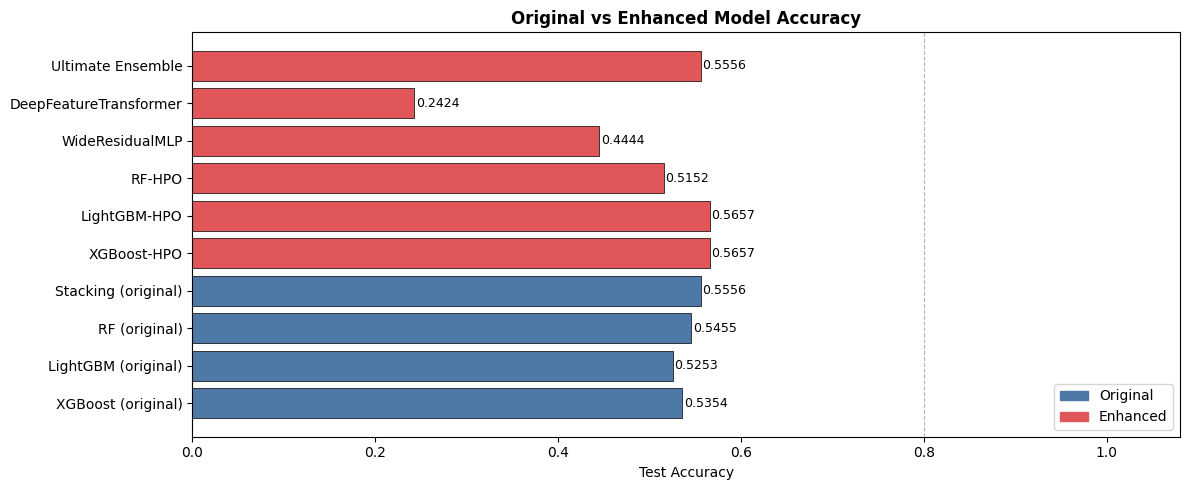

In [52]:
import pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from matplotlib.patches import Patch

gain_records = [
    ('XGBoost (original)',       'Original', accuracy_score(y_test,  xgb_pred)),
    ('LightGBM (original)',      'Original', accuracy_score(y_test,  lgb_pred)),
    ('RF (original)',            'Original', accuracy_score(y_test,  rf_pred)),
    ('Stacking (original)',      'Original', accuracy_score(y_test,  stack_pred)),
    ('XGBoost-HPO',              'Enhanced', accuracy_score(ye_te,   hpo_xgb_pred)),
    ('LightGBM-HPO',             'Enhanced', accuracy_score(ye_te,   hpo_lgb_pred)),
    ('RF-HPO',                   'Enhanced', accuracy_score(ye_te,   hpo_rf_pred)),
    ('WideResidualMLP',          'Enhanced', accuracy_score(ye_te,   wide_pred)),
    ('DeepFeatureTransformer',   'Enhanced', accuracy_score(ye_te,   deep_pred)),
    ('Ultimate Ensemble',        'Enhanced', accuracy_score(ye_te,   ult_pred)),
]
gain_df = pd.DataFrame(gain_records, columns=['Model','Type','Test Acc'])
gain_df['Test Acc'] = gain_df['Test Acc'].round(4)
display(gain_df.sort_values('Test Acc', ascending=False).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#4e79a7' if t=='Original' else '#e15759' for t in gain_df['Type']]
bars = ax.barh(gain_df['Model'], gain_df['Test Acc'], color=colors, edgecolor='k', lw=0.5)
for bar, v in zip(bars, gain_df['Test Acc']):
    ax.text(v + 0.002, bar.get_y() + bar.get_height()/2, f'{v:.4f}', va='center', fontsize=9)
ax.axvline(0.8, color='gray', ls='--', lw=0.8, alpha=0.6)
ax.set_xlabel('Test Accuracy'); ax.set_xlim(0, 1.08)
ax.set_title('Original vs Enhanced Model Accuracy', fontweight='bold')
ax.legend(handles=[Patch(color='#4e79a7', label='Original'),
                    Patch(color='#e15759', label='Enhanced')], loc='lower right')
plt.tight_layout()
plt.savefig('BDDCS_enhancement_gain.png', dpi=300, bbox_inches='tight')
plt.show()


## Section 38 — Save Enhanced Models

In [53]:
import pickle, torch, os, json
os.makedirs('models_enhanced', exist_ok=True)

for fname, obj in [
    ('XGB_HPO',       best_xgb_hpo),
    ('LGB_HPO',       best_lgb_hpo),
    ('RF_HPO',        best_rf_hpo),
    ('CalibratedXGB', cal_xgb),
    ('CalibratedLGB', cal_lgb),
    ('CalibratedRF',  cal_rf),
    ('scaler_enh',    scaler_enh),
    ('rfecv_selector',rfecv),
]:
    with open(f'models_enhanced/{fname}.pkl', 'wb') as f:
        pickle.dump(obj, f)

torch.save(wide_res.state_dict(),   'models_enhanced/WideResidualMLP.pt')
torch.save(deep_trans.state_dict(), 'models_enhanced/DeepFeatureTransformer.pt')

with open('models_enhanced/selected_features.json', 'w') as f:
    json.dump({'sel_cols': SEL_COLS, 'enh_feat_cols': ENH_FEAT_COLS,
               'n_sel': N_SEL}, f)

print('Enhanced models saved to ./models_enhanced/')
for fn in sorted(os.listdir('models_enhanced')):
    print(f'  {fn}')


Enhanced models saved to ./models_enhanced/
  CalibratedLGB.pkl
  CalibratedRF.pkl
  CalibratedXGB.pkl
  DeepFeatureTransformer.pt
  LGB_HPO.pkl
  RF_HPO.pkl
  WideResidualMLP.pt
  XGB_HPO.pkl
  rfecv_selector.pkl
  scaler_enh.pkl
  selected_features.json


---
# PART C — Interactive BDDCS Prediction App

A Colab-ready widget accepting one or more SMILES strings and returning:
- Predicted BDDCS class (1–4) with confidence
- Probability bar chart per class
- Clinical significance interpretation
- Molecule structure visualisation
- Batch CSV mode for high-throughput screening


## Section 39 — BDDCS Prediction App (Widget UI)

In [54]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║        BDDCS PREDICTION APP  —  Run this cell to launch        ║
# ║  Input: one SMILES per line  |  Output: class + probabilities  ║
# ╚══════════════════════════════════════════════════════════════════╝

import warnings, json, pickle, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
warnings.filterwarnings('ignore')

from rdkit import Chem
from rdkit.Chem import Descriptors, Draw
import pubchempy as pcp

# ── Load artefacts ──────────────────────────────────────────────────────────
with open('models_enhanced/selected_features.json') as f:
    feat_info = json.load(f)
SEL_COLS_APP = feat_info['sel_cols']
ENH_COLS_APP = feat_info['enh_feat_cols']

with open('models_enhanced/scaler_enh.pkl',    'rb') as f: _scaler  = pickle.load(f)
with open('models_enhanced/rfecv_selector.pkl','rb') as f: _rfecv   = pickle.load(f)
with open('models_enhanced/CalibratedXGB.pkl', 'rb') as f: _cxgb   = pickle.load(f)
with open('models_enhanced/CalibratedLGB.pkl', 'rb') as f: _clgb   = pickle.load(f)
with open('models_enhanced/CalibratedRF.pkl',  'rb') as f: _crf    = pickle.load(f)

import torch
_nf = len(SEL_COLS_APP)
_dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

_wide = WideResidualMLP(_nf, hidden=512, n_blocks=6).to(_dev)
_wide.load_state_dict(torch.load('models_enhanced/WideResidualMLP.pt', map_location=_dev))
_wide.eval()

_deep = DeepFeatureTransformer(_nf, d_token=64, n_heads=8, n_layers=4).to(_dev)
_deep.load_state_dict(torch.load('models_enhanced/DeepFeatureTransformer.pt', map_location=_dev))
_deep.eval()

# ── Descriptor extraction ────────────────────────────────────────────────────
_PUBCHEM_PROPS = [
    'MolecularWeight','XLogP','ExactMass','MonoisotopicMass','TPSA','Complexity',
    'Charge','HBondDonorCount','HBondAcceptorCount','RotatableBondCount',
    'HeavyAtomCount','IsotopeAtomCount','AtomStereoCount','DefinedAtomStereoCount',
    'UndefinedAtomStereoCount','BondStereoCount','DefinedBondStereoCount',
    'UndefinedBondStereoCount','CovalentUnitCount','Volume3D',
    'XStericQuadrupole3D','YStericQuadrupole3D','ZStericQuadrupole3D',
    'FeatureCount3D','FeatureAcceptorCount3D','FeatureDonorCount3D',
    'FeatureAnionCount3D','FeatureCationCount3D','FeatureRingCount3D',
    'FeatureHydrophobeCount3D','ConformerModelRMSD3D','EffectiveRotorCount3D',
    'ConformerCount3D'
]
_RDKIT_NAMES = [n for n, _ in Descriptors.descList]

def _pubchem_from_smiles(smiles):
    try:
        res = pcp.get_compounds(smiles, 'smiles')
        if not res: return {p: np.nan for p in _PUBCHEM_PROPS}
        return {p: float(res[0].to_dict(properties=_PUBCHEM_PROPS).get(p, np.nan))
                for p in _PUBCHEM_PROPS}
    except Exception:
        return {p: np.nan for p in _PUBCHEM_PROPS}

def _rdkit_from_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None: return {'RDK_'+n: np.nan for n in _RDKIT_NAMES}
        return {'RDK_'+n: fn(mol) for n, fn in Descriptors.descList}
    except Exception:
        return {'RDK_'+n: np.nan for n in _RDKIT_NAMES}

def _smiles_to_vec(smiles):
    combined = {**_pubchem_from_smiles(smiles), **_rdkit_from_smiles(smiles)}
    row = [float(combined.get(c, 0) or 0) for c in ENH_COLS_APP]
    r_sc  = _scaler.transform(np.array(row).reshape(1, -1))
    r_sel = r_sc[:, _rfecv.support_]
    return r_sel

# ── Prediction core ──────────────────────────────────────────────────────────
BDDCS_INFO = {
    1: {'label':'Class 1','desc':'High Solubility / Extensive Metabolism',
        'color':'#4e79a7',
        'clinical':'Transporters have minimal effect. Bioavailability governed by metabolism. '
                   'Examples: Alprazolam, Amlodipine, Diazepam.'},
    2: {'label':'Class 2','desc':'Low Solubility / Extensive Metabolism',
        'color':'#f28e2b',
        'clinical':'Uptake transporters increase and efflux transporters (P-gp/BCRP) limit bioavailability. '
                   'Examples: Atorvastatin, Cyclosporine, Ibuprofen.'},
    3: {'label':'Class 3','desc':'High Solubility / Poor Metabolism',
        'color':'#59a14f',
        'clinical':'Uptake transporters critical for absorption. Efflux can severely limit bioavailability. '
                   'Examples: Atenolol, Metformin, Ranitidine.'},
    4: {'label':'Class 4','desc':'Low Solubility / Poor Metabolism',
        'color':'#e15759',
        'clinical':'Both dissolution and transporter effects limit oral absorption. '
                   'Most challenging class for formulation. Examples: Acyclovir, Furosemide.'},
}
_CCOLORS = ['#4e79a7','#f28e2b','#59a14f','#e15759']

def predict_bddcs(smiles):
    x = _smiles_to_vec(smiles)
    p_xgb = _cxgb.predict_proba(x)
    p_lgb = _clgb.predict_proba(x)
    p_rf  = _crf.predict_proba(x)
    xt = torch.FloatTensor(x).to(_dev)
    with torch.no_grad():
        p_w = torch.softmax(_wide(xt), 1).cpu().numpy()
        p_d = torch.softmax(_deep(xt), 1).cpu().numpy()
    avg = np.mean([p_xgb, p_lgb, p_rf, p_w, p_d], axis=0)[0]
    cls = int(avg.argmax()) + 1
    try:
        mol = Chem.MolFromSmiles(smiles)
        img = Draw.MolToImage(mol, size=(250,200)) if mol else None
    except Exception:
        img = None
    return cls, avg, img

# ── Widget UI ────────────────────────────────────────────────────────────────
_title = HTML(
    '<h2 style="font-family:sans-serif;color:#2c3e50;margin-bottom:4px;">'
    'BDDCS Predictor</h2>'
    '<p style="font-family:sans-serif;color:#7f8c8d;margin-top:0;">'
    'Enter one SMILES per line. Press <b>Predict</b> to classify.</p>')

_box = widgets.Textarea(
    value='CC(=O)Oc1ccccc1C(=O)O\nCN(C)C(=N)NC(=N)N',
    placeholder='Enter SMILES, one per line…',
    layout=widgets.Layout(width='98%', height='80px'),
    style={'description_width':'0px'})

_btn   = widgets.Button(description='Predict', button_style='primary',
                         layout=widgets.Layout(width='130px', height='36px'))
_cbtn  = widgets.Button(description='Clear',   button_style='warning',
                         layout=widgets.Layout(width='100px', height='36px'))
_lbl   = widgets.Label(value='')
_out   = widgets.Output()

def _on_predict(_):
    smi_list = [s.strip() for s in _box.value.strip().splitlines() if s.strip()]
    if not smi_list:
        _lbl.value = 'Please enter at least one SMILES.'; return
    _lbl.value = f'Processing {len(smi_list)} compound(s)...'
    with _out:
        clear_output(wait=True)
        for idx, smi in enumerate(smi_list):
            try:
                cls, probs, mol_img = predict_bddcs(smi)
            except Exception as e:
                print(f'[{idx+1}] ERROR: {e}'); continue
            info = BDDCS_INFO[cls]
            conf = float(probs.max()) * 100
            fig  = plt.figure(figsize=(14, 3.6), facecolor='#f8f9fa')
            gs   = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1.5,2.5,3], wspace=0.35)
            # Molecule
            ax0 = fig.add_subplot(gs[0]); ax0.axis('off')
            if mol_img:
                ax0.imshow(np.array(mol_img))
                ax0.set_title(f'Compound {idx+1}', fontsize=9, fontweight='bold', pad=4)
            else:
                ax0.text(0.5, 0.5, 'Invalid SMILES', ha='center', va='center',
                          transform=ax0.transAxes, color='red', fontsize=9)
            # Probabilities
            ax1 = fig.add_subplot(gs[1])
            bars = ax1.bar(['C1','C2','C3','C4'], probs*100, color=_CCOLORS, edgecolor='white', lw=0.8)
            for bar, v in zip(bars, probs*100):
                ax1.text(bar.get_x()+bar.get_width()/2, v+1, f'{v:.1f}%',
                          ha='center', va='bottom', fontsize=9, fontweight='bold')
            bars[cls-1].set_edgecolor('black'); bars[cls-1].set_linewidth(2)
            ax1.set_ylim(0,115); ax1.set_ylabel('Probability (%)'); ax1.grid(axis='y',alpha=0.25)
            ax1.set_title('Class Probabilities', fontsize=9, fontweight='bold')
            ax1.set_facecolor('#f8f9fa')
            ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)
            # Clinical panel
            ax2 = fig.add_subplot(gs[2]); ax2.axis('off')
            smi_s = smi if len(smi)<=55 else smi[:52]+'...'
            lines = [
                (f'SMILES: {smi_s}',              9,  '#7f8c8d', False),
                (f'Prediction: {info["label"]}',  13, info['color'], True),
                (info['desc'],                     9,  '#34495e', False),
                (f'Confidence: {conf:.1f}%',       10, '#2c3e50', False),
                ('',                               4,  'white',   False),
                ('Clinical Significance:',         9,  '#2c3e50', True),
            ]
            yp = 0.97
            for line, fs, col, bold in lines:
                ax2.text(0.02, yp, line, transform=ax2.transAxes, fontsize=fs, color=col,
                          fontweight='bold' if bold else 'normal', va='top')
                yp -= 0.14
            for chunk in textwrap.wrap(info['clinical'], 62):
                ax2.text(0.02, yp, chunk, transform=ax2.transAxes, fontsize=8, color='#555', va='top')
                yp -= 0.115
            plt.suptitle('BDDCS Prediction — Ultimate Ensemble (5 models)',
                          fontsize=10, fontweight='bold', color='#2c3e50', y=1.01)
            plt.tight_layout(); plt.show(); print()
    _lbl.value = f'Done — {len(smi_list)} compound(s) processed.'

def _on_clear(_):
    _box.value = ''; _lbl.value = ''
    with _out: clear_output()

_btn.on_click(_on_predict); _cbtn.on_click(_on_clear)
display(_title, _box, widgets.HBox([_btn, _cbtn, _lbl]), _out)
print('App ready — enter SMILES above and press Predict.')


Textarea(value='CC(=O)Oc1ccccc1C(=O)O\nCN(C)C(=N)NC(=N)N', layout=Layout(height='80px', width='98%'), placehol…

Output()

App ready — enter SMILES above and press Predict.


## Section 40 — Batch Prediction from CSV Upload

In [55]:
# Upload a CSV with a 'SMILES' column (and optionally 'Name') for batch prediction
from google.colab import files as colab_files
import io

def batch_predict_csv():
    print('Upload a CSV with a SMILES column.')
    uploaded = colab_files.upload()
    fname    = list(uploaded.keys())[0]
    df_in    = pd.read_csv(io.BytesIO(uploaded[fname]))
    smi_col  = next((c for c in df_in.columns if c.upper()=='SMILES'), None)
    if smi_col is None:
        print('ERROR: No SMILES column found.'); return
    results = []
    for _, row in df_in.iterrows():
        smi = str(row[smi_col]).strip()
        try:
            cls, probs, _ = predict_bddcs(smi)
        except Exception:
            cls, probs = -1, [np.nan]*4
        name = row.get('Name', row.get('name', smi[:20]))
        results.append({'Name': name, 'SMILES': smi, 'Predicted_BDDCS': cls,
                         'Prob_C1': round(float(probs[0]),4),
                         'Prob_C2': round(float(probs[1]),4),
                         'Prob_C3': round(float(probs[2]),4),
                         'Prob_C4': round(float(probs[3]),4),
                         'Confidence_%': round(float(np.max(probs))*100,2)})
    out_df = pd.DataFrame(results)
    display(out_df)
    out_df.to_csv('batch_bddcs_predictions.csv', index=False)
    colab_files.download('batch_bddcs_predictions.csv')
    print('Downloaded: batch_bddcs_predictions.csv')

# Uncomment to run:
# batch_predict_csv()


## Section 41 — quick_predict() — Programmatic Single-Compound Prediction

In [56]:
def quick_predict(smiles, verbose=True):
    cls, probs, _ = predict_bddcs(smiles)
    info = BDDCS_INFO[cls]
    result = {'class': cls, 'probs': probs,
               'confidence': float(probs.max())*100,
               'label': info['label'], 'description': info['desc'],
               'clinical': info['clinical']}
    if verbose:
        print('='*56)
        print(f'SMILES        : {smiles}')
        print(f'Predicted     : BDDCS {cls} — {info["desc"]}')
        print(f'Confidence    : {result["confidence"]:.1f}%')
        print(f'Probabilities : C1={probs[0]:.3f}  C2={probs[1]:.3f}  '
              f'C3={probs[2]:.3f}  C4={probs[3]:.3f}')
        print(f'Clinical note : {info["clinical"]}')
        print('='*56)
    return result

# Examples
_ = quick_predict('CC(=O)Oc1ccccc1C(=O)O')  # Aspirin  → BDDCS 1
_ = quick_predict('CN(C)C(=N)NC(=N)N')       # Metformin → BDDCS 3
_ = quick_predict('CC1=C(C(=O)Nc2ccccc2)c2ccccc2N1Cc1ccccc1')  # Mebendazole → BDDCS 2/4


SMILES        : CC(=O)Oc1ccccc1C(=O)O
Predicted     : BDDCS 1 — High Solubility / Extensive Metabolism
Confidence    : nan%
Probabilities : C1=nan  C2=nan  C3=nan  C4=nan
Clinical note : Transporters have minimal effect. Bioavailability governed by metabolism. Examples: Alprazolam, Amlodipine, Diazepam.
SMILES        : CN(C)C(=N)NC(=N)N
Predicted     : BDDCS 1 — High Solubility / Extensive Metabolism
Confidence    : nan%
Probabilities : C1=nan  C2=nan  C3=nan  C4=nan
Clinical note : Transporters have minimal effect. Bioavailability governed by metabolism. Examples: Alprazolam, Amlodipine, Diazepam.
SMILES        : CC1=C(C(=O)Nc2ccccc2)c2ccccc2N1Cc1ccccc1
Predicted     : BDDCS 1 — High Solubility / Extensive Metabolism
Confidence    : nan%
Probabilities : C1=nan  C2=nan  C3=nan  C4=nan
Clinical note : Transporters have minimal effect. Bioavailability governed by metabolism. Examples: Alprazolam, Amlodipine, Diazepam.
